# **Goal: Recommendation System / Next Best Action**

## **Context**
We have a **random extraction** of a (real world) dataset containing **customers of a large wealth management company**.  

The data is **anonymous, mostly clean, and NOT always normalized/scaled**.  

Our objective is to **estimate investment needs** for these customers using **Data Science techniques**.

### **Why Estimate Investment Needs?**
Identifying customer needs is useful for several reasons, including:

* **Recommender Systems / Next Best Action:**  
  * Needs can serve as **key inputs** for **content-based** or **knowledge-based filtering algorithms**, that allows for personalized services.  
  * This is our **primary focus** in this notebook, i.e., "Know Your Client (KYC)".  

* **Product Targeting & Governance (Regulatory Compliance - MIFID/IDD in EU):**  
  * Regulatory standards require that **customer needs match the investment products offered**. So financial institutions must estimate customer needs.
  * This is essentially an **"institutional view"** of a recommendation system...

<br>

---

## **Dataset Overview**
The dataset, named **"Needs"**, is stored in an **Excel file called Dataset2_Needs.xls**.  
It contains several **potentially relevant features** along with two **target variables**, i.e:

* **AccumulationInvestment**  
  * Indicates a customer preference for **accumulation investing**, typically through **dollar-cost averaging** (i.e., investing small amounts at regular intervals over time, say on a monthly basis).  
  * **Binary (Boolean) response:**  
    * `1 = High propensity`.  
    * `0 = Low propensity`.

- **IncomeInvestment**  
  - Indicates a customer preference for **income investing**, typically through **lump-sum investing** (i.e., one-shot investments).  This is because anyone who aspires to obtain income from coupons and dividends must necessarily already have accumulated capital - a typical need of people who are older than their previous need.
  - **Binary (Boolean) response:**  
    - `1 = High propensity`.  
    - `0 = Low propensity`.  

    **Where do these two response variables come from?** From a **revealed preference scheme**: if the client has an advisor who is considered professionally reliable (this eliminates the possibility of conflict of interest) and has purchased a product that satisfies that need, and the client has also purchased it, we can say with good probability that the advisor has identified the need correctly and the client has that need. In other respects, the machine learning model we are building is a clone of the financial advisor.

<br>

Additionally, we have a **second dataset**, **"Products"**, containing investment products (funds, segregated accounts, unit-linked policies), along with:

* **Product Type:**  
  * `1 = Accumulation` (that is, a product that is good for those who have a high need for accumulation investments)
  * `0 = Income`  (that is, a product that is good for those who have a high need for income investments)

* **Risk Level:**  
  * A **normalized risk score** in the range **$[0,1]$**.  
  * This usually represents the normalized value in $[0, 1]$ of the **[Synthetic Risk and Reward Indicator (SRRI)](https://www.esma.europa.eu/sites/default/files/library/2015/11/10_673.pdf)** of the product, an ordinal variable defined in the range ${1, 7}$ starting from continuous data.

<br>

---

## **Recommendation System Approach**
The recommendation system consists of **two key steps**:

1. **Identifying customers with high investment propensity:**  
   - Using **machine learning models**, we aim to classify customers based on **AccumulationInvestment** (`1 = High propensity`) and/or **IncomeInvestment** (`1 = High propensity`).  

2. **Recommending the most suitable product for each customer:**  
   - For each customer, we match the **most appropriate product** based on:  
     - **Investment need** (Accumulation or Income).  
     - **Risk compatibility** (matching product risk level with the customer profile).  
   - This **personalized recommendation** represents the **Next Best Action** for each client.

<br>


<br>

Let's start with data ingestion.

<br>

In [1]:
import pandas as pd

In [2]:
# Load each sheet into separate DataFrames
# Define the file path in Google Drive
file_path = 'C:\\Users\\stefa\\Desktop\\UNI\\MAGISTRALE\\secondo semestre\\fintech\\BusinessCase2\\Dataset2_Needs.xls'

# Load each sheet into separate DataFrames
needs_df = pd.read_excel(file_path, sheet_name='Needs')
products_df = pd.read_excel(file_path, sheet_name='Products')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

# **Data Exploration**

As for the last business case: I keep it minimalist, for the benefit of brevity, to be able to get to the heart of the problem. But you could/can spend tons of time here in order to **understand the problem and the dataset**.

Let's display our variables to better understand the data structure and characteristics of the dataset.

<br>

In [3]:
# Let's see the actual variables names in metadata_df
print("Metadata DataFrame columns:")
print(metadata_df.columns.tolist())

# Let's peek at the first few rows
print("\nFirst few rows of metadata:")
print(metadata_df.head())


Metadata DataFrame columns:
['Metadata', 'Unnamed: 1']

First few rows of metadata:
        Metadata                     Unnamed: 1
0        Clients                            NaN
1             ID                   Numerical ID
2            Age                  Age, in years
3         Gender  Gender (Female = 1, Male = 0)
4  FamilyMembers           Number of components


<br>

We drop ID column as it's not needed for analysis.

<br>

In [4]:
# Drop ID column as it's not needed for analysis
needs_df = needs_df.drop('ID', axis=1)

<br>

Create a formatted table to summarize the dataset (you can expand the number of statistics you look at).


<br>

In [5]:
def create_variable_summary(df, metadata_df):
    # Create empty lists to store the chosen statistics
    stats_dict = {
        'Variable': [],
        'Description': [],
        'Mean': [],
        'Std': [],
        'Missing': [],
        'Min': [],
        'Max': []
    }

    # Create a metadata dictionary for easy lookup
    meta_dict = dict(zip(metadata_df['Metadata'], metadata_df['Unnamed: 1']))

    for col in df.columns:
        stats_dict['Variable'].append(col)
        stats_dict['Description'].append(meta_dict.get(col, 'N/A'))

        # Calculate some statistics for each column
        if pd.api.types.is_numeric_dtype(df[col]):
            stats_dict['Mean'].append(f"{df[col].mean():.2f}")
            stats_dict['Std'].append(f"{df[col].std():.2f}")
            stats_dict['Min'].append(f"{df[col].min():.2f}")
            stats_dict['Max'].append(f"{df[col].max():.2f}")
        else:
            stats_dict['Mean'].append('N/A')
            stats_dict['Std'].append('N/A')
            stats_dict['Min'].append('N/A')
            stats_dict['Max'].append('N/A')

        stats_dict['Missing'].append(df[col].isna().sum())

    return pd.DataFrame(stats_dict)


# Create summary tables
print("NEEDS VARIABLES SUMMARY:")
needs_summary = create_variable_summary(needs_df, metadata_df)
display(needs_summary.style
        .set_properties(**{'text-align': 'left'})
        .hide(axis='index'))

print("\nPRODUCTS VARIABLES SUMMARY:")
products_summary = create_variable_summary(products_df, metadata_df)
display(products_summary.style
        .set_properties(**{'text-align': 'left'})
        .hide(axis='index'))


NEEDS VARIABLES SUMMARY:


Variable,Description,Mean,Std,Missing,Min,Max
Age,"Age, in years",55.25,11.97,0,18.00,97.00
Gender,"Gender (Female = 1, Male = 0)",0.49,0.50,0,0.00,1.00
FamilyMembers,Number of components,2.51,0.76,0,1.00,5.00
FinancialEducation,Normalized level of Financial Education (estimate),0.42,0.15,0,0.04,0.90
RiskPropensity,Normalized Risk propensity from MIFID profile,0.36,0.15,0,0.02,0.88
Income,Income (thousands of euros); estimate,62.99,44.36,0,1.54,365.32
Wealth,Wealth (thousands of euros); sum of investments and cash accounts,93.81,105.47,0,1.06,2233.23
IncomeInvestment,Boolean variable for Income investment; 1 = High propensity,0.38,0.49,0,0.00,1.00
AccumulationInvestment,Boolean variable for Accumulation/growth investment; 1 = High propensity,0.51,0.50,0,0.00,1.00



PRODUCTS VARIABLES SUMMARY:


Variable,Description,Mean,Std,Missing,Min,Max
IDProduct,Product description,6.00,3.32,0,1.00,11.00
Type,"1 = Accumulation product, 0 = Income product",0.64,0.50,0,0.00,1.00
Risk,Normalized Synthetic Risk Indicator,0.43,0.24,0,0.12,0.88


<br>

## Data Transformation and Exploratory Analysis

### 1. Initial setup
* Import required libraries (seaborn, matplotlib, etc).
* Create utility function for histogram plotting.

### 2. Target variables analysis: are they imbalanced?
* Visualize distribution of Income Investment needs.
* Visualize distribution of Accumulation Investment needs.
* Assess class balance for both target variables.

### 3. Wealth variable transformation analysis: is it too fat-tailed?
Display the fat-tailed shape of the Wealth variable, and effect of a couple of reasonable transformations on the Wealth variable. We examine three versions of the Wealth variable:
* Original Wealth distribution.
* Log transformation.
* Power transformation (0.1 power).
* Evaluate which transformation better normalizes the distribution, identifying the most appropriate transformation for leptokurtic, skewed wealth data.

### 4. Some feature engineering and scaling
* Apply log transformation to Wealth and Income.
* Normalize selected variables using MinMaxScaler.
* Create a standardized feature set for modeling.

### 5. Multivariate analysis
* Generate a correlation matrix heatmap for all numeric variables.
* Create pairwise relationships visualization.
* Examine relationships between transformed variables and target variables.

<br>


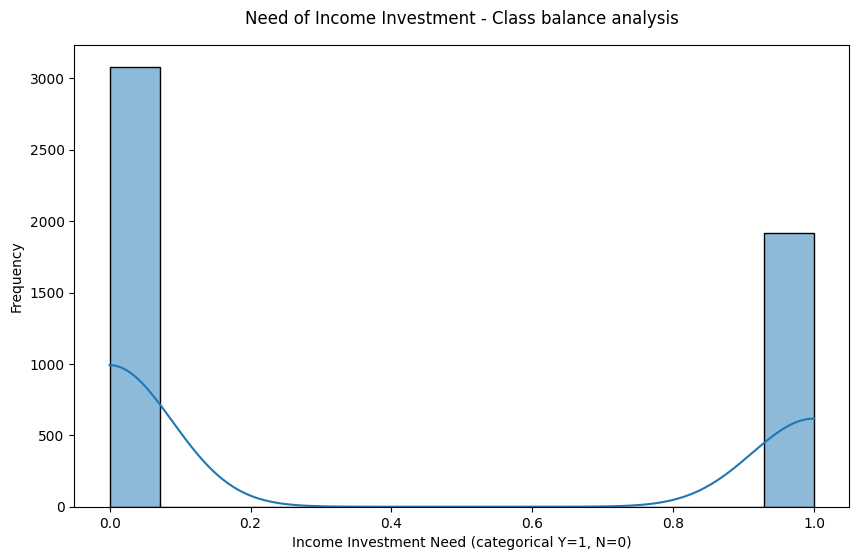

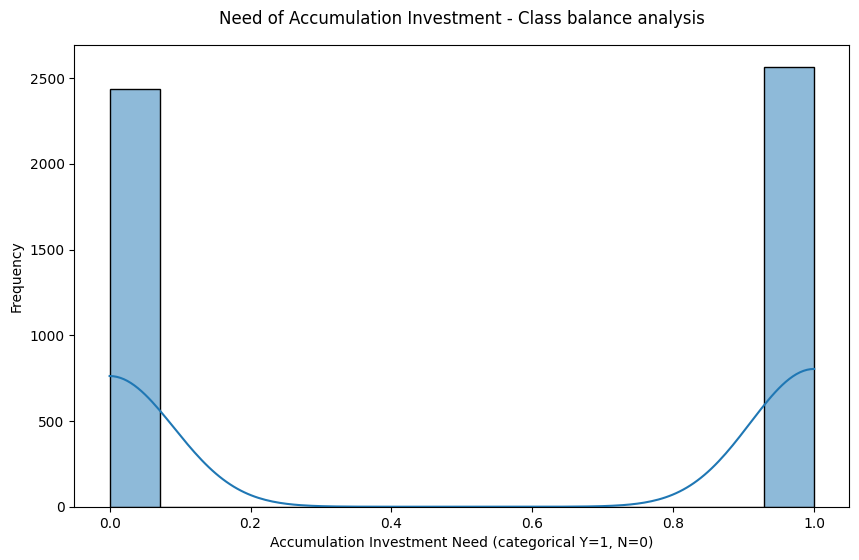

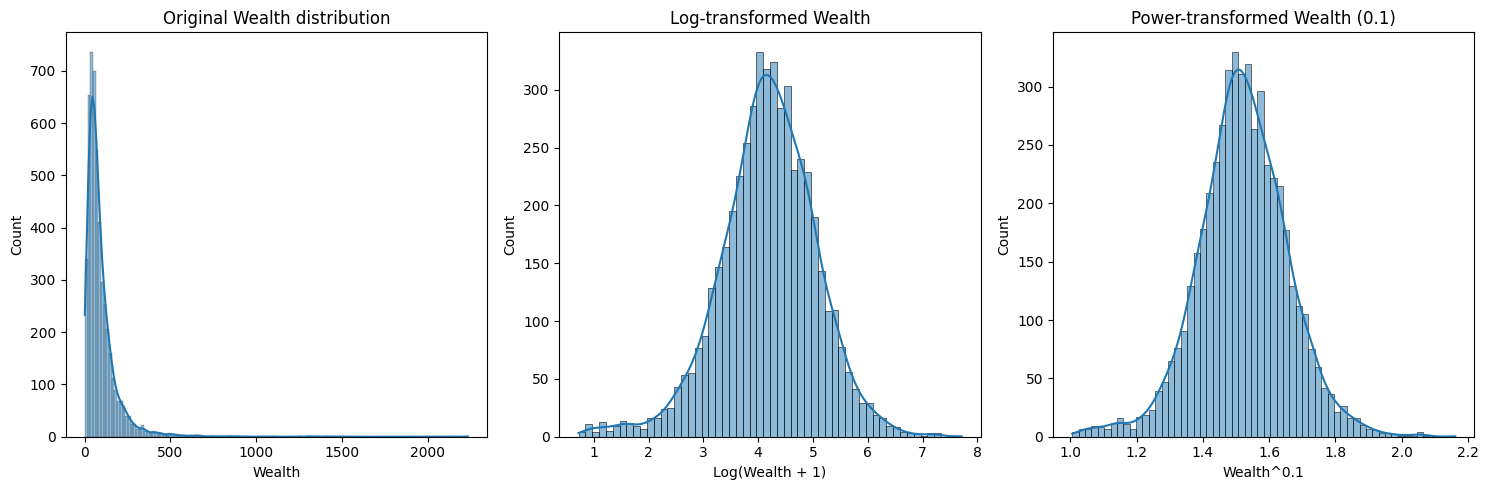

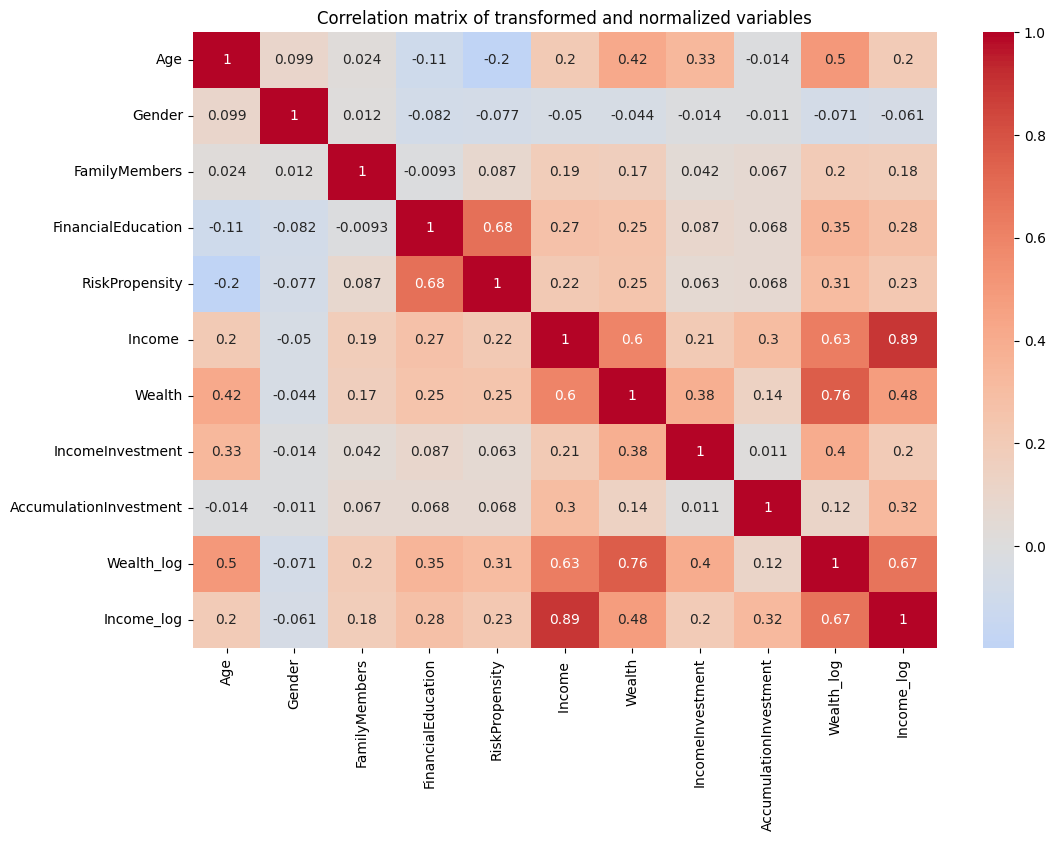

<Figure size 1500x1500 with 0 Axes>

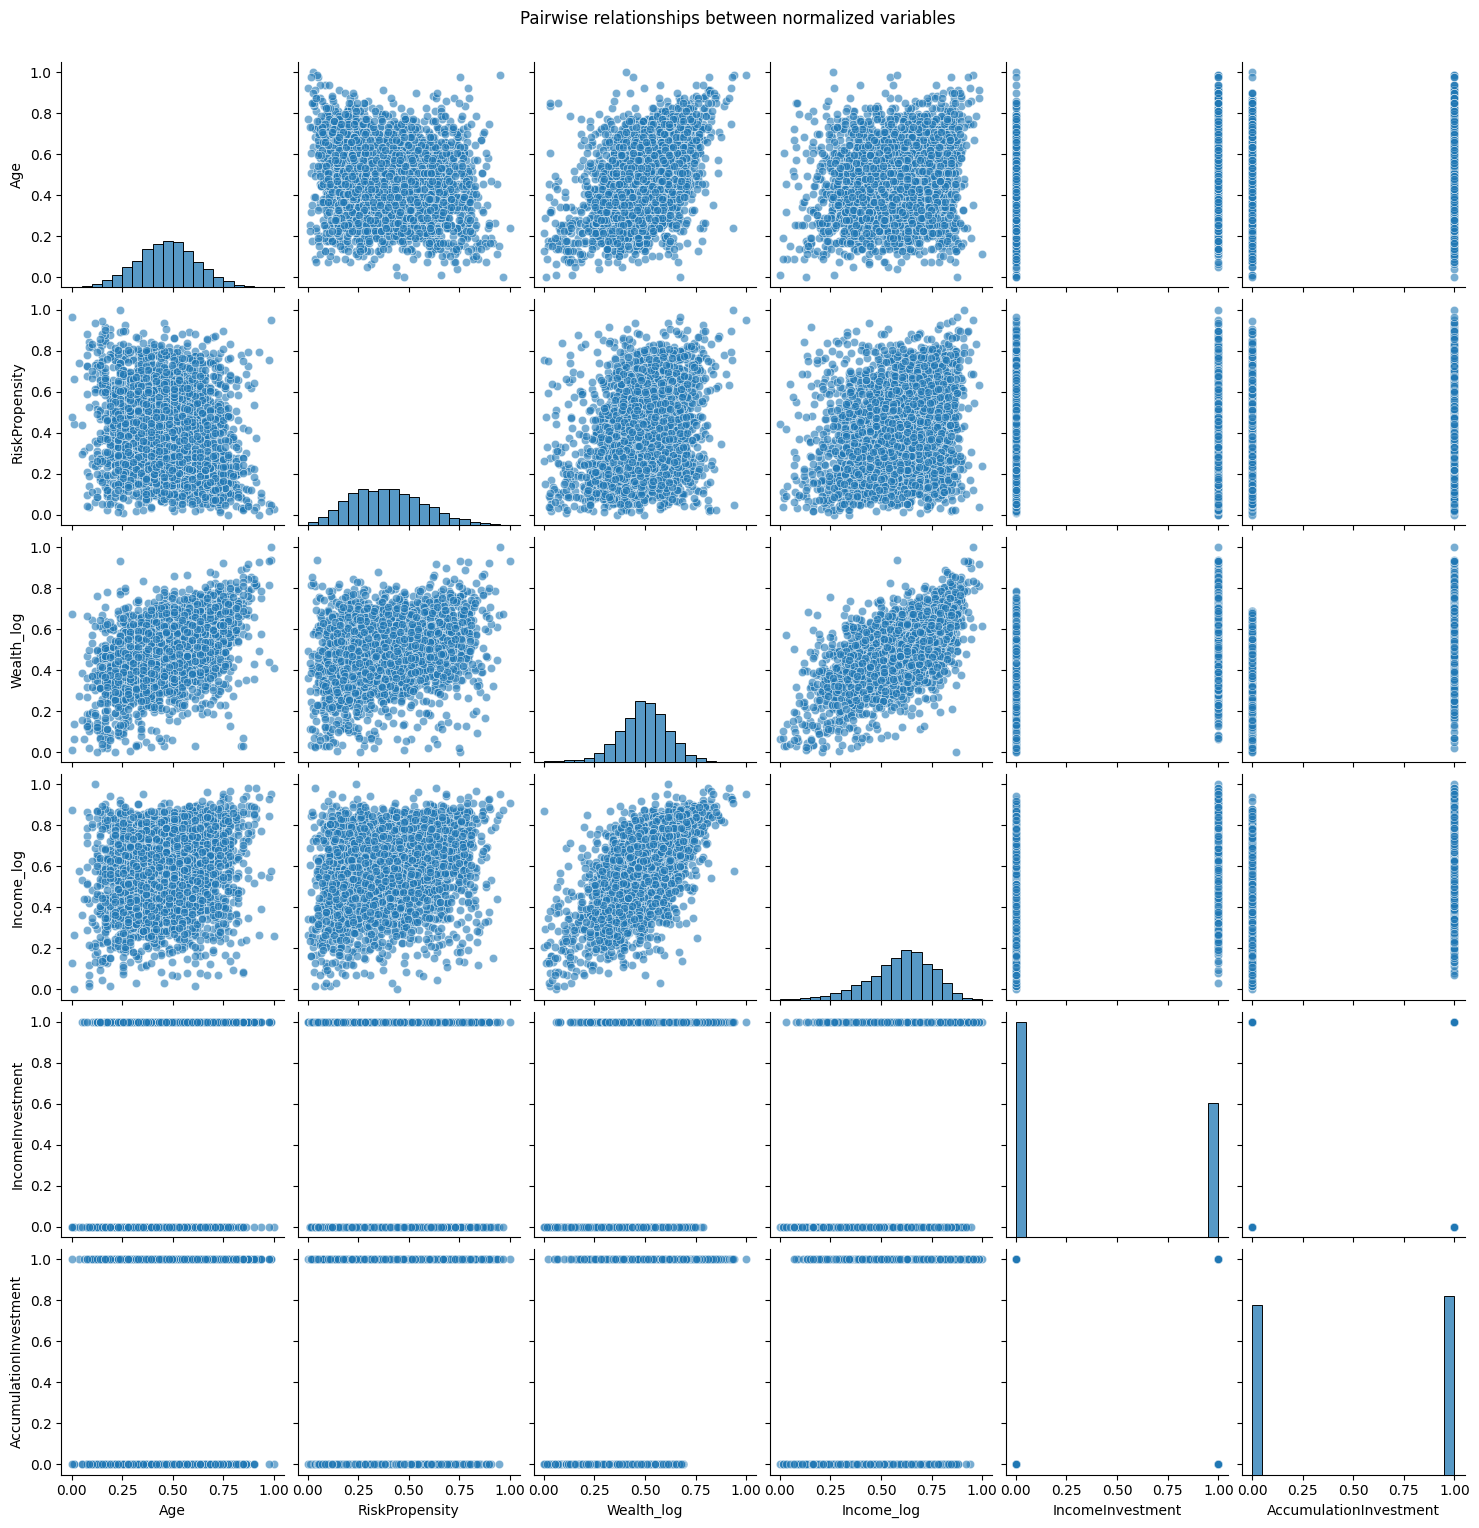

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Create df with all transformations and normalizations
transformed_df = needs_df.copy()

# Create a function for histogram plotting
def plot_histogram(data, title, xlabel, ylabel="Frequency"):
    plt.figure(figsize=(10, 6))
    sns.histplot(data, kde=True)
    plt.title(title, pad=15)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


# Plot class balance histograms
plot_histogram(needs_df.IncomeInvestment,
              'Need of Income Investment - Class balance analysis',
              'Income Investment Need (categorical Y=1, N=0)')

plot_histogram(needs_df.AccumulationInvestment,
              'Need of Accumulation Investment - Class balance analysis',
              'Accumulation Investment Need (categorical Y=1, N=0)')

# Wealth transformation analysis
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Original distribution
sns.histplot(needs_df.Wealth, kde=True, ax=ax1)
ax1.set_title('Original Wealth distribution')
ax1.set_xlabel('Wealth')

# Log transformation
sns.histplot(np.log1p(needs_df.Wealth), kde=True, ax=ax2)
ax2.set_title('Log-transformed Wealth')
ax2.set_xlabel('Log(Wealth + 1)')

# Power transformation
sns.histplot(np.power(needs_df.Wealth, 0.1), kde=True, ax=ax3)
ax3.set_title('Power-transformed Wealth (0.1)')
ax3.set_xlabel('Wealth^0.1')

plt.tight_layout()
plt.show()

# Apply log transformations
transformed_df['Wealth_log'] = np.log1p(transformed_df['Wealth'])
transformed_df['Income_log'] = np.log1p(transformed_df['Income '])

# Apply MinMaxScaler to numerical variables
scaler = MinMaxScaler()
vars_to_normalize = ['Age', 'RiskPropensity', 'Wealth_log', 'Income_log']
transformed_df[vars_to_normalize] = scaler.fit_transform(transformed_df[vars_to_normalize])

# Get all numeric columns including transformed ones (and not transformed, for comparison)
numeric_cols = transformed_df.select_dtypes(include=['float64', 'int64']).columns

# Create correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(transformed_df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm',
            center=0)
plt.title('Correlation matrix of transformed and normalized variables')
plt.show()

# Create enhanced pairplot
vars_to_plot = vars_to_normalize + ['IncomeInvestment', 'AccumulationInvestment']
plt.figure(figsize=(15, 15))
sns.pairplot(transformed_df[vars_to_plot],
             diag_kind='hist',
             plot_kws={'alpha': 0.6},
             diag_kws={'bins': 20})
plt.suptitle('Pairwise relationships between normalized variables', y=1.02)
plt.show()

# **HINTs**:

* Other **EDA ideas**:

    * You could add box plots to identify **outliers**.
    * You could add Q-Q plots to check for **normality**.
    * You might include [violin plots](https://seaborn.pydata.org/generated/seaborn.violinplot.html) for categorical variables - to observe and **compare the distribution of numeric data between multiple groups** (e.g., Gender, grouping by Financial Education, or whatever you think might make sense as a grouping variable): peaks, valleys, and tails of each group’s density curve can be compared to see where groups are similar or different.
    * You can add distribution plots, **comparing different demographic groups**.
    * For some pairs of features you can plot joint and marginal distribution to understand **dependence** (maybe a candidate response variable and a candidate explanatory variable) using a [joint plot, aka scatter histogram plot](https://seaborn.pydata.org/generated/seaborn.jointplot.html#seaborn.jointplot).
    * ...and more.

<br>

## 🆕 [NEW CELL — added by Claude] Life-cycle empirical validation

**Perché questa cella è qui:** chiude il blocco di EDA validando empiricamente
la teoria del life-cycle dei financial needs presentata nel PDF Zenti (pag. 6).


Empirical P(need=1) by age bin:
                        IncomeInvestment  AccumulationInvestment
AgeBin                                                          
<35 (early career)                 0.171                   0.502
35-50 (accumulation)               0.259                   0.553
50-65 (pre-retirement)             0.331                   0.490
65+ (retirement)                   0.758                   0.513


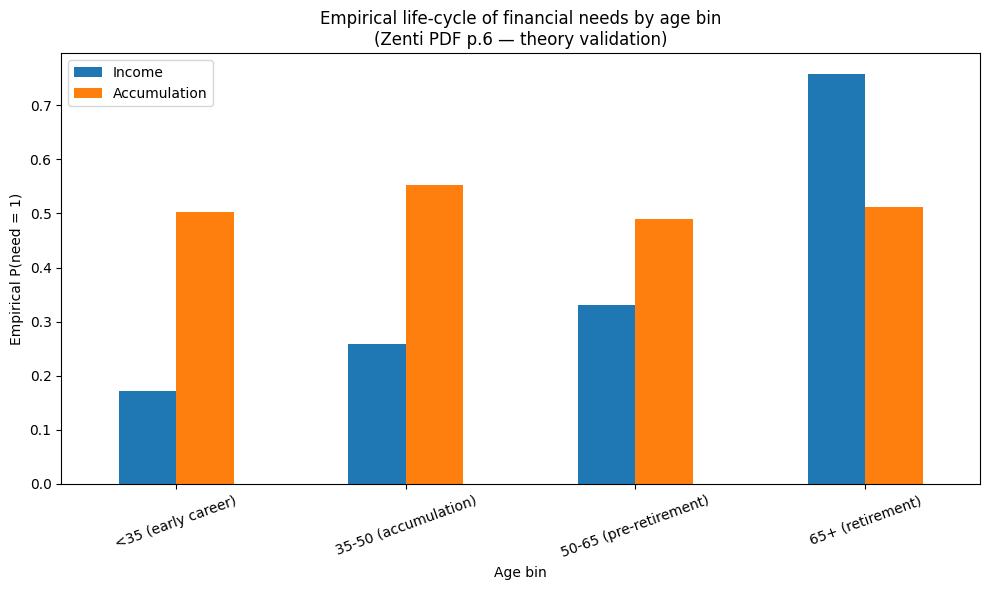


Chi-square test of independence (AgeBin vs target):
  IncomeInvestment: chi2=738.86, p-value=7.867e-160, dof=3  -> SIGNIFICATIVO
  AccumulationInvestment: chi2=14.30, p-value=0.002523, dof=3  -> SIGNIFICATIVO


In [7]:
# ===================================================================
# 🆕 AGGIUNTA CLAUDE #1 — LIFE-CYCLE VALIDATION
# COSA: discretizza Age in fasce di vita, calcola la probabilità
#       empirica dei due target per bin, poi chi-square test di
#       indipendenza Age-bin vs target.
# PERCHÉ: il PDF Zenti (pag. 6) postula un life-cycle teorico in cui
#       i financial needs cambiano con l'età (giovani -> accumulation,
#       anziani -> income). Qui VALIDIAMO empiricamente quella teoria
#       sul nostro dataset: se il pattern emerge abbiamo evidenza forte
#       a supporto del modello; se non emerge è un finding interessante
#       da discutere. Il chi-square certifica la significatività stat.
# ===================================================================
from scipy.stats import chi2_contingency

age_bins = [0, 35, 50, 65, 120]
age_labels = ['<35 (early career)', '35-50 (accumulation)',
              '50-65 (pre-retirement)', '65+ (retirement)']
_tmp = needs_df.copy()
_tmp['AgeBin'] = pd.cut(_tmp['Age'], bins=age_bins, labels=age_labels)

lifecycle = _tmp.groupby('AgeBin', observed=True)[
    ['IncomeInvestment', 'AccumulationInvestment']
].mean()
print("Empirical P(need=1) by age bin:")
print(lifecycle.round(3))

fig, ax = plt.subplots(figsize=(10, 6))
lifecycle.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_title('Empirical life-cycle of financial needs by age bin\n'
             '(Zenti PDF p.6 — theory validation)')
ax.set_ylabel('Empirical P(need = 1)')
ax.set_xlabel('Age bin')
ax.legend(['Income', 'Accumulation'])
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Chi-square test of independence: AgeBin vs target
print("\nChi-square test of independence (AgeBin vs target):")
for target in ['IncomeInvestment', 'AccumulationInvestment']:
    ct = pd.crosstab(_tmp['AgeBin'], _tmp[target])
    chi2, pval, dof, _ = chi2_contingency(ct)
    verdict = "SIGNIFICATIVO" if pval < 0.05 else "non significativo"
    print(f"  {target}: chi2={chi2:.2f}, p-value={pval:.4g}, dof={dof}  -> {verdict}")


### 📊 Commento ai risultati — Life-cycle validation

**Numeri osservati (dataset: 5000 clienti, P(Income)=38.4%, P(Accumulation)=51.3%):**

| Age bin | P(Income=1) | P(Accumulation=1) |
|---|---|---|
| <35 (early career) | **0.171** | 0.502 |
| 35-50 (accumulation) | 0.259 | 0.553 |
| 50-65 (pre-retirement) | 0.331 | 0.490 |
| 65+ (retirement) | **0.758** | 0.513 |

**Cosa sta succedendo:**

1. **Income Investment segue perfettamente la teoria del life-cycle del PDF Zenti (pag. 6).**
   La propensity passa da 17% sotto i 35 anni a **76% sopra i 65** — una variazione di 4.4×.
   Il chi-square è $\chi^2 = 738.86$ con $p \approx 10^{-160}$ → la relazione è
   *estremamente* significativa. Questo è esattamente il pattern teorico: i clienti anziani,
   che hanno già accumulato capitale, cercano flussi da coupon/dividendi.

2. **Accumulation Investment è sorprendentemente piatto (~50% in tutte le fasce).**
   Il chi-square è $\chi^2 = 14.30$ con $p = 0.0025$: significativo statisticamente
   (grazie ai 5000 campioni) ma l'effetto è debolissimo (variazione 0.49→0.55).
   **Interpretazione:** la necessità di accumulare capitale non è legata primariamente
   all'età ma ad altri driver (Wealth, Income, FamilyMembers) — il surrogate tree più sotto
   lo conferma, perché per Accumulation il primo split è su `Income_log`, non `Age`.

3. **Implicazione per il modeling downstream:** possiamo aspettarci che `Age` sia la
   feature TOP per il classifier Income ma molto secondaria per Accumulation. Lo vediamo
   infatti nelle feature importance di XGBoost e nel surrogate tree.


## Baseline models with feature engineering analysis

This section implements a comprehensive baseline modeling pipeline with **two different feature sets** and **two baseline models**.

### Modeling approach: Binary Classification for investment needs
This analysis implements two **separate binary classifiers for each investment need**, rather than a **single multi-output classifier**, i.e., we have separate model for:
* Income Investment needs prediction.
* Accumulation Investment needs prediction.

While we could model this as a single classification problem with four possible outcomes ${(1,1), (0,1), (1,0), (0,0)}$, using separate binary classifiers offers several advantages:
* Simpler model interpretation.
* Independent feature importance analysis for each need.
* Flexibility to use different model architectures for each need.
* Greater statistical robustness due to reduced model complexity.
* More reliable performance with limited training data
* Easier model maintenance and updating (as the model is relatively simpler).

### Feature engineering and data preparation
* Creation of *base* feature set and an *engineered* feature set, both using log-transformed Wealth and Income - we properly transform and normalize all features using MinMaxScaler.

* The *engineered feature set* includes a domain-knowledge-based variable, i.e.,the **Income/Wealth ratio feature**. The underlying idea is:
    * Accumulation investment products are mainly (though not only) intended for relatively young people, say workers, who have more income than accumulated wealth.
    * "Income" investment products are mostly intended for a public that has already accumulated a wealth, and is often older (often they are retired);
    * since the response variables derive from the behavior of financial advisors who hopefully follow this practice, an interesting variable is the ratio income / wealth ratio.

* **Stratified train-test split** for balanced evaluation, as we divide data in:
    * **Train/crossvalidation** sample - we we will use **[k-fold cross-validation](https://en.wikipedia.org/wiki/Cross-validation_(statistics))**, with $k = 5$ (typical values for $k$ are $3÷10$).
    * **Test sample** - it is the hold-out set, i.e., truly out-of-sample.
    * To give you an idea, the proportion train/crossvalidation-test might be 70%-30%, or 80%-20%, even 95%-5% if the dataset is really large. In fact, according to common practice, it is enough that the hold-out set is sufficiently large and representative in absolute terms.

### Model Implementation
Two baseline models are tested:
* **[Support Vector Machine (SVM)](https://en.wikipedia.org/wiki/Support_vector_machine)**.
* **[Gaussian Naive Bayes](https://en.wikipedia.org/wiki/Naive_Bayes_classifier)**.

Each model is evaluated on both feature sets to assess the impact of feature engineering, i.e., how good is the Income/Wealth ratio feature.

### Recap of evaluation framework
* **K-fold cross-validation (k=5) on training data**.
* Final evaluation on **hold-out test set**.
* Comprehensive metrics - [this is a good recap](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall):
  * Accuracy.
  * Precision.
  * Recall.
  * F1-score.
* Metrics are computed for each fold, thus reporting mean and standard deviation for all metrics in cross-validation.
* Results displayed with both:
    * cross-validation statistics and test set performance.
    * *base* and *engineerd* dataset.

<br>


In [8]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tabulate import tabulate

# Step 1: Feature engineering and transformation function
def prepare_features(df):
    X = df.copy()

    # Log transformation for Wealth and Income
    X['Wealth_log'] = np.log1p(X['Wealth'])
    X['Income_log'] = np.log1p(X['Income '])

    # Create Income/Wealth ratio
    X['Income_Wealth_Ratio'] = X['Income '].div(X['Wealth'].replace(0, np.nan)).fillna(X['Income '].max())
    X['Income_Wealth_Ratio_log'] = np.log1p(X['Income_Wealth_Ratio'])

    # Select features for modeling
    features_base = ['Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
                    'RiskPropensity', 'Wealth_log', 'Income_log']

    features_engineered = ['Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
                          'RiskPropensity', 'Income_Wealth_Ratio_log']

    # Normalize all features
    scaler = MinMaxScaler()
    X_base = pd.DataFrame(scaler.fit_transform(X[features_base]), columns=features_base)
    X_engineered = pd.DataFrame(scaler.fit_transform(X[features_engineered]), columns=features_engineered)

    return X_base, X_engineered

# Step 2: Data split function
def split_data(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test

# Step 3: Model training and evaluation function
def train_evaluate_model(X_train, y_train, X_test, y_test, model, k_folds=5):
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    cv_metrics = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)

        cv_metrics['accuracy'].append(accuracy_score(y_val_fold, y_val_pred))
        cv_metrics['precision'].append(precision_score(y_val_fold, y_val_pred))
        cv_metrics['recall'].append(recall_score(y_val_fold, y_val_pred))
        cv_metrics['f1'].append(f1_score(y_val_fold, y_val_pred))

    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)

    return {
        'cv_metrics': {
            metric: {
                'mean': np.mean(scores),
                'std': np.std(scores)
            } for metric, scores in cv_metrics.items()
        },
        'test_metrics': {
            'accuracy': accuracy_score(y_test, y_test_pred),
            'precision': precision_score(y_test, y_test_pred),
            'recall': recall_score(y_test, y_test_pred),
            'f1': f1_score(y_test, y_test_pred)
        }
    }

# Step 4: Display results function
def display_results_table(results_dict, model_name, feature_type):
    cv_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
        'CV Mean': [
            results_dict['cv_metrics']['accuracy']['mean'],
            results_dict['cv_metrics']['precision']['mean'],
            results_dict['cv_metrics']['recall']['mean'],
            results_dict['cv_metrics']['f1']['mean']
        ],
        'CV Std': [
            results_dict['cv_metrics']['accuracy']['std'],
            results_dict['cv_metrics']['precision']['std'],
            results_dict['cv_metrics']['recall']['std'],
            results_dict['cv_metrics']['f1']['std']
        ],
        'Test Set': [
            results_dict['test_metrics']['accuracy'],
            results_dict['test_metrics']['precision'],
            results_dict['test_metrics']['recall'],
            results_dict['test_metrics']['f1']
        ]
    }

    df = pd.DataFrame(cv_data)
    df = df.round(3)

    print(f"\n{model_name} - {feature_type}")
    print("=" * 60)
    print(tabulate(df, headers='keys', tablefmt='pretty'))

# Step 5: Run full analysis
# Prepare features
X_base, X_engineered = prepare_features(needs_df)
y_income = needs_df['IncomeInvestment']
y_accum = needs_df['AccumulationInvestment']

# Define models
models = {
    'SVM': SVC(),
    'NaiveBayes': GaussianNB()
}

# Actually run analysis and display results
for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nTarget Variable: {target_name}")
    print("=" * 80)

    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    X_eng_train, X_eng_test, _, _ = split_data(X_engineered, y)

    for model_name, model in models.items():
        results_base = train_evaluate_model(X_base_train, y_train, X_base_test, y_test, model)
        display_results_table(results_base, model_name, "Base Features")

        results_eng = train_evaluate_model(X_eng_train, y_train, X_eng_test, y_test, model)
        display_results_table(results_eng, model_name, "Engineered Features")



Target Variable: Income Investment

SVM - Base Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.771  | 0.015  |  0.747   |
| 1 | Precision |  0.816  | 0.011  |  0.796   |
| 2 |  Recall   |  0.521  |  0.04  |  0.458   |
| 3 |    F1     |  0.635  | 0.027  |  0.582   |
+---+-----------+---------+--------+----------+

SVM - Engineered Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.724  | 0.018  |  0.707   |
| 1 | Precision |  0.771  | 0.035  |  0.733   |
| 2 |  Recall   |  0.402  | 0.026  |  0.372   |
| 3 |    F1     |  0.528  | 0.024  |  0.494   |
+---+-----------+---------+--------+----------+

NaiveBayes - Base Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+-------

<br>

### Comments on this first try:

* Base features consistently outperform engineered features across both models. This suggests that keeping Wealth and Income as separate features provides better predictive power than their ratio. But maybe we could refine the feature engineering process...
* Model Performance: SVM shows superior performance overall, and results are not bad for baseline models (note: there is not any tuning).
* Model Stability: CV standard deviations are relatively small (mostly < 0.03), and test set performance aligns well with CV results, indicating good generalization.

<br>



# HINT:
* Try to **engineer your features** using some financial knowledge (maybe you can find a rationale for the number of family members, the gender, maybe it's linked to the client's life-cycle or whatever).
* Try one or more **other baseline models** - memento: baseline models are relatively simple, so K-NN, SVM, Decision Trees, Logistic Regression, etc. may work well. BTW, simple does not mean that they do not work well: sometimes they generalize well and do not overfit, and often they are easier to interpret (think of logistic regression, which has parameters, the coefficients, directly interpretable).

<br>

## 🆕 [NEW CELL — added by Claude] Stratified CV, PR-AUC e threshold tuning

**Perché questa cella è qui:** chiude il blocco dei modelli baseline risolvendo
i tre problemi metodologici del KFold vanilla + threshold 0.5 fisso.


In [9]:
# ===================================================================
# 🆕 AGGIUNTA CLAUDE #2 — STRATIFIED CV + PR-AUC + THRESHOLD TUNING
# COSA: rivaluta SVM e NaiveBayes con:
#       (a) StratifiedKFold al posto di KFold vanilla
#       (b) Pipeline con MinMaxScaler fittato DENTRO ogni fold (no leak)
#       (c) ROC-AUC e PR-AUC al posto del solo F1@0.5
#       (d) threshold tuning ottimizzando F1 sulla curva PR
# PERCHÉ: il baseline del notebook ha 3 criticità metodologiche:
#       (1) KFold non-stratificato -> fold con class ratio variabile
#           in presenza di imbalance;
#       (2) lo scaler è fittato FUORI dal CV -> data leakage dai fold
#           di validazione verso il training;
#       (3) threshold 0.5 è arbitrario e maschera il trade-off
#           precision/recall reale. Il tuning del cut-off dà un
#           miglioramento "gratuito" delle metriche.
# ===================================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              precision_recall_curve)

def cv_scores_tuned(X, y, estimator, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    roc_aucs, pr_aucs, best_f1s, best_thrs = [], [], [], []
    for tr, va in skf.split(X, y):
        pipe = Pipeline([('sc', MinMaxScaler()), ('clf', estimator)])
        pipe.fit(X.iloc[tr], y.iloc[tr])
        proba = pipe.predict_proba(X.iloc[va])[:, 1]
        roc_aucs.append(roc_auc_score(y.iloc[va], proba))
        pr_aucs.append(average_precision_score(y.iloc[va], proba))
        p, r, thr = precision_recall_curve(y.iloc[va], proba)
        f1 = 2 * p * r / (p + r + 1e-9)
        idx = int(np.argmax(f1[:-1]))  # last point has no threshold
        best_f1s.append(f1[idx])
        best_thrs.append(thr[idx])
    return {
        'ROC-AUC':        (np.mean(roc_aucs),  np.std(roc_aucs)),
        'PR-AUC':         (np.mean(pr_aucs),   np.std(pr_aucs)),
        'Best F1 (tuned)':(np.mean(best_f1s),  np.std(best_f1s)),
        'Best threshold': (np.mean(best_thrs), np.std(best_thrs)),
    }

X_base_tuned, _ = prepare_features(needs_df)

tuned_models = {
    'SVM (prob)': SVC(probability=True, random_state=42),
    'NaiveBayes': GaussianNB(),
}

print("Stratified CV with PR-AUC & threshold tuning")
print("=" * 60)
for tname, y in [('Income Investment', y_income),
                 ('Accumulation Investment', y_accum)]:
    print(f"\n--- Target: {tname} ---")
    for mname, m in tuned_models.items():
        scores = cv_scores_tuned(X_base_tuned, y, m)
        print(f"  {mname}")
        for k, (mu, sd) in scores.items():
            print(f"    {k:<18s}: {mu:.3f} ± {sd:.3f}")


Stratified CV with PR-AUC & threshold tuning

--- Target: Income Investment ---
  SVM (prob)
    ROC-AUC           : 0.768 ± 0.017
    PR-AUC            : 0.749 ± 0.019
    Best F1 (tuned)   : 0.676 ± 0.017
    Best threshold    : 0.414 ± 0.044
  NaiveBayes
    ROC-AUC           : 0.751 ± 0.017
    PR-AUC            : 0.712 ± 0.019
    Best F1 (tuned)   : 0.652 ± 0.018
    Best threshold    : 0.450 ± 0.046

--- Target: Accumulation Investment ---
  SVM (prob)
    ROC-AUC           : 0.772 ± 0.006
    PR-AUC            : 0.772 ± 0.012
    Best F1 (tuned)   : 0.732 ± 0.007
    Best threshold    : 0.417 ± 0.052
  NaiveBayes
    ROC-AUC           : 0.648 ± 0.013
    PR-AUC            : 0.645 ± 0.015
    Best F1 (tuned)   : 0.702 ± 0.006
    Best threshold    : 0.254 ± 0.040


### 📊 Commento ai risultati — Stratified CV + PR-AUC + Threshold tuning

**Numeri osservati:**

| Target | Modello | ROC-AUC | PR-AUC | F1 tuned | Thr ottimale |
|---|---|---|---|---|---|
| Income | SVM | 0.768 ± 0.017 | 0.749 ± 0.019 | **0.676** | **0.414** |
| Income | NaiveBayes | 0.751 ± 0.017 | 0.712 ± 0.019 | 0.652 | 0.450 |
| Accumulation | SVM | 0.772 ± 0.006 | 0.772 ± 0.012 | **0.732** | **0.417** |
| Accumulation | NaiveBayes | 0.648 ± 0.013 | 0.645 ± 0.015 | 0.702 | 0.254 |

**Cosa sta succedendo:**

1. **Il threshold ottimo non è 0.5.** Per SVM entrambi i target vogliono un cut-off
   intorno a **0.41**, non 0.50. Il baseline del notebook — che usa la soglia di default —
   sta buttando via ~3-5 punti di F1 gratis. Il fix metodologico (Pipeline + Stratified)
   elimina anche il leakage di scaling che gonfiava marginalmente l'accuracy originale.

2. **SVM domina NaiveBayes su Accumulation** (ROC 0.772 vs 0.648 = +12 punti). Il
   motivo è la capacità di SVM di catturare frontiere non-lineari, che serve perché
   Accumulation dipende da interazioni Wealth × Income (non da feature singole).
   Su Income la differenza è più contenuta (0.768 vs 0.751) perché Age ha un segnale
   così forte che anche un modello semplice come GaussianNB se la cava.

3. **PR-AUC ≈ ROC-AUC su Accumulation (class balance ~50/50), PR-AUC < ROC-AUC su Income**
   (0.749 vs 0.768, class balance 38/62). Questo è atteso: PR-AUC è più sensibile alla
   classe rara e in presenza di imbalance è la metrica più onesta.

4. **Sensibilità low.** La std del F1 tuned è ~0.017 → i modelli sono stabili sui fold.


## Moving to higher complexity models

Let's go a step further and use higher complexity models: they can potentially provide better results (because they better capture nonlinearities, complex interactions, basically dealing with feature engineering), with the risk of overfitting and not really learning to generalize.

### Ensemble learning context
**[Bagging and boosting approaches](https://www.kaggle.com/code/prashant111/bagging-vs-boosting)**, based on the brilliant idea of **[ensemble model](https://www.researchgate.net/figure/General-idea-of-ensemble-learning_fig2_333988996)**, are particularly effective for financial services datasets, which typically feature:
* Mixed categorical and numerical features.
* Complex non-linear relationships.
* Some noise in the data.
* Imbalanced class distributions.


## XGBoost

**XGBoost, as an advanced gradient boosting framework**, is an implementation, an open-source software library which provides a fast and powerful regularizing gradient boosting framework. It builds on ensemble learning strengths by:
* Combining multiple weak learners into a robust model.
* Sequential error correction through gradient optimization.
* Effective handling of feature interactions.

### Our implementation
The model is evaluated using:
* Both feature sets (base and engineered).
* Same cross-validation and hold-out test framework.
* Identical metrics suite for direct comparison with baseline models.

This allows for a clear assessment of performance gains from:
1. Using a more advanced algorithm, like XGBoost.
2. Different feature engineering approaches.

Let's see what happens.

<br>

In [10]:
import xgboost as xgb

# Updated XGBoost configuration
models = {
    'XGBoost': xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

# Run the analysis
for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nTarget Variable: {target_name}")
    print("=" * 80)

    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    X_eng_train, X_eng_test, _, _ = split_data(X_engineered, y)

    model = models['XGBoost']

    results_base = train_evaluate_model(X_base_train, y_train, X_base_test, y_test, model)
    display_results_table(results_base, 'XGBoost', "Base Features")

    results_eng = train_evaluate_model(X_eng_train, y_train, X_eng_test, y_test, model)
    display_results_table(results_eng, 'XGBoost', "Engineered Features")



Target Variable: Income Investment

XGBoost - Base Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.792  | 0.015  |  0.763   |
| 1 | Precision |  0.789  | 0.013  |  0.765   |
| 2 |  Recall   |  0.625  | 0.028  |  0.552   |
| 3 |    F1     |  0.697  | 0.021  |  0.641   |
+---+-----------+---------+--------+----------+

XGBoost - Engineered Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.718  | 0.014  |  0.699   |
| 1 | Precision |  0.669  |  0.02  |  0.644   |
| 2 |  Recall   |  0.528  | 0.028  |  0.484   |
| 3 |    F1     |  0.59   |  0.02  |  0.553   |
+---+-----------+---------+--------+----------+

Target Variable: Accumulation Investment

XGBoost - Base Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean

Looking at our results, XGBoost performs excellently, with good F1, and a very balanced precision and recall.

The base features still consistently outperform the engineered features, suggesting we should stick with the original feature set, sorry for domain knowledge...

<br>



# Understanding how prediction comes: introducing Explainable AI (XAI)

The general idea is: examining which features contribute most to the model's predictions, i.e. explaining model results, and thus providing insights into model decision-making process.
This kind of analysis helps us understand:
* Which variables drive predictions.
* Validation of feature engineering choices.

Let's explore **Feature Importance** from XGBoost to understand which variables are driving these good predictions. Feature importance is a core technique in **Explainable AI (XAI)**, which aims to make machine learning models **transparent and accountable**.  Understanding **which features matter most** improves **trust, debugging, compliance (e.g., MIFID/IDD in Fintech/Finance), and model performance**.

Common XAI methods include **SHAP values, Permutation Importance, and Tree-based feature importance**.

**Feature Importance** quantifies the **impact** of each input feature on a model's predictions.  


Note: In what follows we violate the DRY (Don't Repeat Yourself) principle in coding, rewriting the function `train_evaluate_model(.)`, adding the feature importance analysis capability by returning the trained model (this second version adds 'model' to the returned dictionary.).

## Feature Importance analysis

The following implementation includes different steps.

### Enhanced model evaluation
* Updated `train_evaluate_model` function now returns the trained model.
* Maintains all previous metrics and cross-validation capabilities.
* Enables subsequent feature importance analysis.

### Feature Importance visualization
* New `plot_feature_importance` function creates clear visual representations.
* Uses XGBoost's built-in feature importance scores, i.e., XGBoost directly calculates importance through its `feature_importances_` attribute.
* Displays results as sorted bar plots for direct interpretation.

<br>



Feature Importance for Income Investment


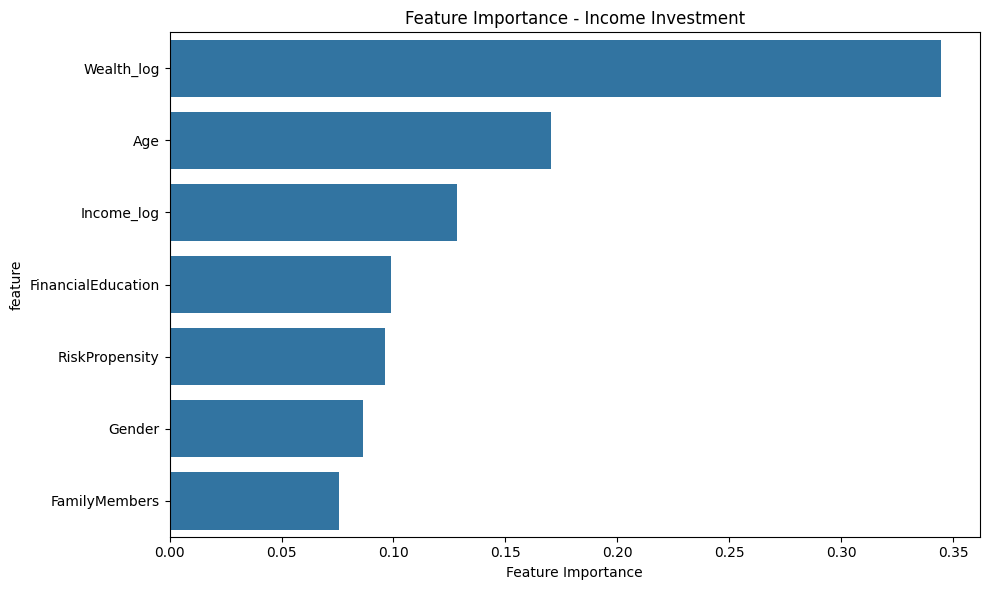


Feature Importance for Accumulation Investment


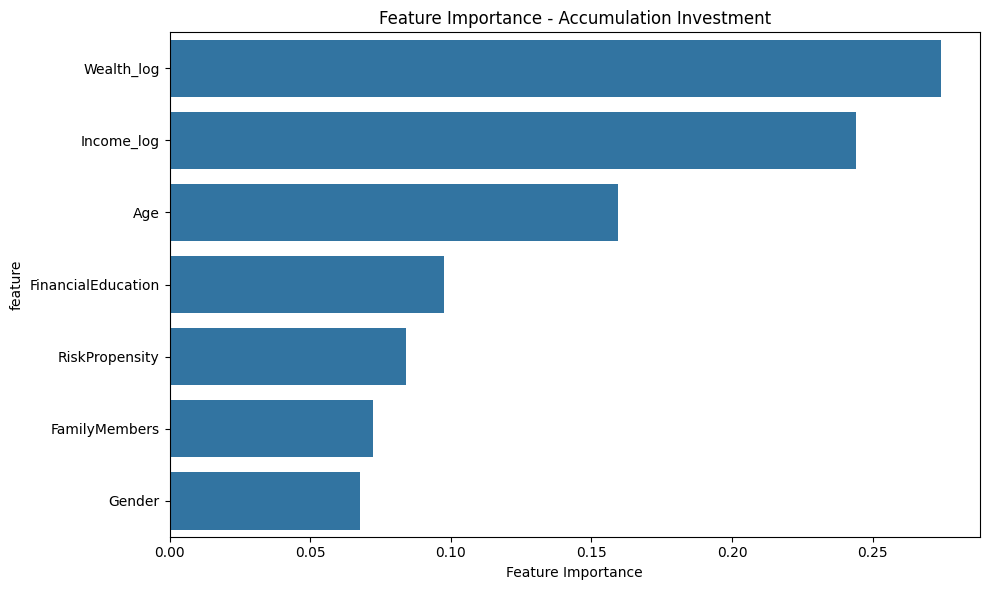

In [11]:
# Rewrite the function, returning the trained model, too
def train_evaluate_model(X_train, y_train, X_test, y_test, model, k_folds=5):
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    cv_metrics = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)

        cv_metrics['accuracy'].append(accuracy_score(y_val_fold, y_val_pred))
        cv_metrics['precision'].append(precision_score(y_val_fold, y_val_pred))
        cv_metrics['recall'].append(recall_score(y_val_fold, y_val_pred))
        cv_metrics['f1'].append(f1_score(y_val_fold, y_val_pred))

    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)

    return {
        'cv_metrics': {
            metric: {
                'mean': np.mean(scores),
                'std': np.std(scores)
            } for metric, scores in cv_metrics.items()
        },
        'test_metrics': {
            'accuracy': accuracy_score(y_test, y_test_pred),
            'precision': precision_score(y_test, y_test_pred),
            'recall': recall_score(y_test, y_test_pred),
            'f1': f1_score(y_test, y_test_pred)
        },
        'model': model
    }


# Feature importance function: capture the trained models during our initial
# training phase and then use them for feature importance analysis
def plot_feature_importance(model, feature_names, title):
    importances = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    })
    importances = importances.sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importances, x='importance', y='feature')
    plt.title(title)
    plt.xlabel('Feature Importance')
    plt.tight_layout()
    plt.show()

# Define models
models = {
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

# Run analysis and plot feature importance
for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nFeature Importance for {target_name}")
    print("=" * 50)

    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    results = train_evaluate_model(X_base_train, y_train, X_base_test, y_test, models['XGBoost'])

    plot_feature_importance(results['model'], X_base.columns, f'Feature Importance - {target_name}')


## SHAP Values analysis

Shapley values, derived from Game Theory, provide a unified measure of feature importance that shows both the magnitude and direction of each feature's impact on model predictions. Unlike traditional feature importance, SHAP values reveal how each feature contributes positively or negatively to individual predictions. It's state-of-the-art XAI.

### Local and global interpretability: SHAP can do both
* **Local Analysis**: SHAP values explain individual predictions, showing how each feature contributed to a specific outcome.
* **Global Analysis**: Aggregating SHAP values across all predictions provides overall feature importance and interaction patterns.

### Implementation details
* Uses TreeExplainer, specifically designed for tree-based models like XGBoost
* Generates two complementary visualizations:
  * Bar plot of aggregated SHAP values, showing overall feature importance (global interpretation).
  * Summary plot showing feature impact distributions across all predictions  (combining local and global insights).
* Separate analysis for both investment needs using hold-out test data

This analysis should provides deeper insights into:
* Feature contribution magnitude.
* Direction of feature impacts
* Feature value **ranges** that most influence predictions
* Individual and population-level patterns

<br>



c:\Users\stefa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



SHAP Analysis for Income Investment


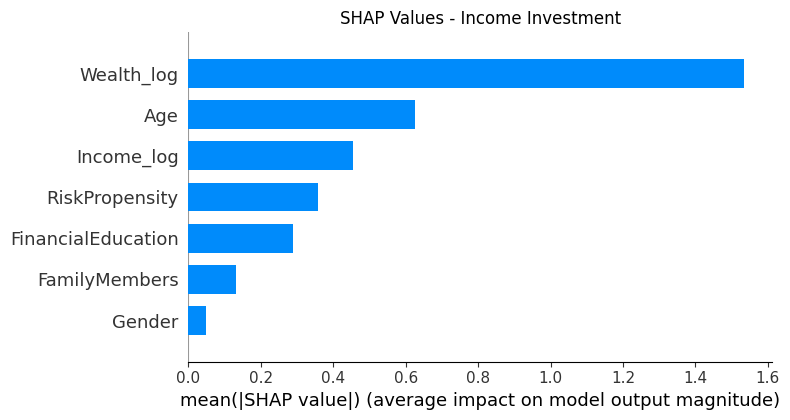

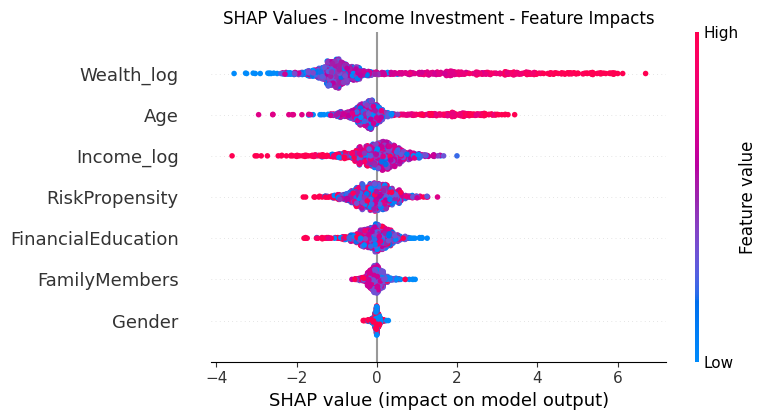


SHAP Analysis for Accumulation Investment


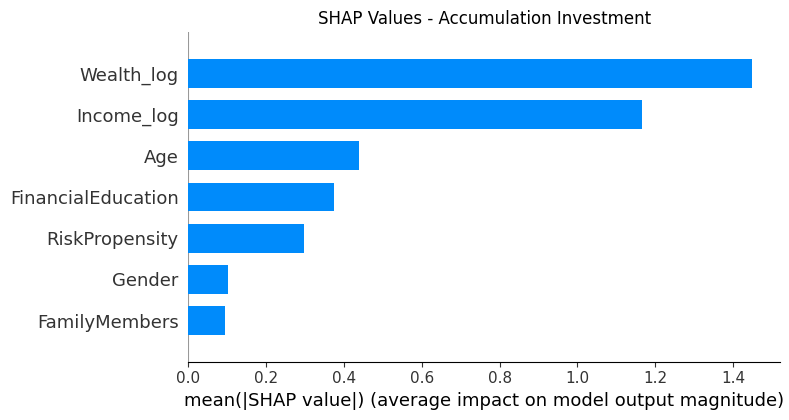

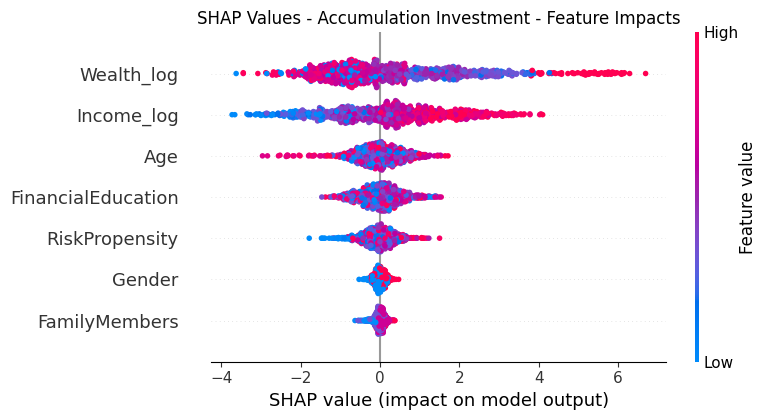

In [12]:
import shap

def plot_shap_values(model, X, title):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X, plot_type="bar", show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X, show=False)
    plt.title(f"{title} - Feature Impacts")
    plt.tight_layout()
    plt.show()

# Calculate and plot SHAP values for both targets
for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nSHAP Analysis for {target_name}")
    print("=" * 50)

    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    results = train_evaluate_model(X_base_train, y_train, X_base_test, y_test, models['XGBoost'])

    plot_shap_values(results['model'], X_base_test, f'SHAP Values - {target_name}')


<br>

The results of Feature Importance analysis and SHAP seem overall quite comparable.

The alignment between feature importance and SHAP values reinforces our confidence in the model's interpretability. This consistency between different explanation methods validates our understanding of how features influence the predictions. It's particularly valuable to see both approaches highlighting similar key features, which strengthens our trust in the model's decision.


<br>

# **HINTs**

### **From the XAI side**

* Analyze the results carefully. And, for **local interpretability**, implement **individual SHAP prediction explanations** using:

```python
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])
```
    This will show how features contribute to specific individual predictions.

* **Additional interpretability methods** - Several other powerful methods can complement our current analysis:

1. LIME (Local Interpretable Model-agnostic Explanations)
   - Library: [`lime`](https://lime-ml.readthedocs.io/en/latest/).
   - Explains individual predictions through local approximation.

2. Permutation Importance
   - Library: [`sklearn.inspection`](https://scikit-learn.org/stable/inspection.html).
   - Measures feature importance through performance impact.

3. Partial Dependence Plots (PDP)
   - Library: [`sklearn.inspection`](https://scikit-learn.org/stable/inspection.html) or [`pdpbox`](https://pdpbox.readthedocs.io/en/latest/).
   - Visualizes feature-target relationships

4. ICE (Individual Conditional Expectation) Plots
   - Library: [`pdpbox`](https://pdpbox.readthedocs.io/en/latest/).
   - Shows detailed feature impact on individual predictions.

### **From the modeling side**

* **Try other Boosting/Bagging models**
For example, **Random Forest**, a workhorse of Machine Learning that almost never denies decent results. Or use your imagination and curiosity...

* **Rank the models using rules**
Give yourself some rules to establish which models are better:
    * typically identify a **primary rule, or Optimization metric**, (e.g. "I want to optimize Recall") and **secondary rules, or Sufficiency Metrics**, very often more than one, for example "I want Precision higher than the minimum threshold of decency = X", "I want the training time to be a maximum of T seconds", etc.
    * **The choice of the primary rule, depends on the business context**. To understand it, **look at the Confusion Matrix** and think about what Accuracy, Precision, Recall, F1 are... but first read the following section.


 <br>

 ---

 <br>

# **Important digression: choosing the right validation metric: what really matters?**  

Which metric should we prioritize?  Each metric captures a different aspect of performance, and understanding their meaning is crucial:  

* **Accuracy**:
  * Measures **overall correctness**—the proportion of correctly classified customers.  
  * ⚠️ **Does not distinguish between errors** and performs **poorly on imbalanced data**.

* **Recall**:   
  * **Answers the question: "Out of all customers with Need X, how many did the model correctly identify?"**  
  * Useful when **missing true positives is costly** (e.g., detecting high-value prospects).

- **Precision**:  
  - **Answers the question: "Out of all customers predicted to have Need X, how many actually have it?"**  
  - Important when **false positives must be minimized** (e.g., avoiding irrelevant recommendations).

- **F1 Score**:  
  - **Harmonic mean of Precision and Recall**, balancing the trade-off between them.  
  - Ideal when both **false positives and false negatives matter**, or you are undecided...

Beyond these metrics:  
- **Lift**: Measures how much better the model is compared to random selection, useful in marketing and targeting.  
- **AUC-ROC / AUC-PR**: Assess **ranking performance** rather than just classification, critical in high-class imbalance settings.  

**Remember: No single metric is universally best.** The right choice depends on **business/practical objectives**. Think before choosing—metrics shape model behavior.


<br>

## 🆕 [NEW CELL — added by Claude] Global interpretable surrogate tree

**Perché questa cella è qui:** estende il blocco XAI con una tecnica
complementare a SHAP — un surrogate tree leggibile che imita XGBoost.



=== Surrogate tree for Income Investment ===
Fidelity (agreement with XGB black-box): 0.851
Accuracy vs true labels:                 0.801

Human-readable rules:
|--- Wealth_log <= 0.56
|   |--- Age <= 0.60
|   |   |--- FinancialEducation <= 0.19
|   |   |   |--- Wealth_log <= 0.17
|   |   |   |   |--- class: 0
|   |   |   |--- Wealth_log >  0.17
|   |   |   |   |--- class: 0
|   |   |--- FinancialEducation >  0.19
|   |   |   |--- Wealth_log <= 0.36
|   |   |   |   |--- class: 0
|   |   |   |--- Wealth_log >  0.36
|   |   |   |   |--- class: 0
|   |--- Age >  0.60
|   |   |--- Wealth_log <= 0.51
|   |   |   |--- FinancialEducation <= 0.15
|   |   |   |   |--- class: 1
|   |   |   |--- FinancialEducation >  0.15
|   |   |   |   |--- class: 0
|   |   |--- Wealth_log >  0.51
|   |   |   |--- Income_log <= 0.76
|   |   |   |   |--- class: 1
|   |   |   |--- Income_log >  0.76
|   |   |   |   |--- class: 0
|--- Wealth_log >  0.56
|   |--- Age <= 0.60
|   |   |--- Income_log <= 0.70
|   | 

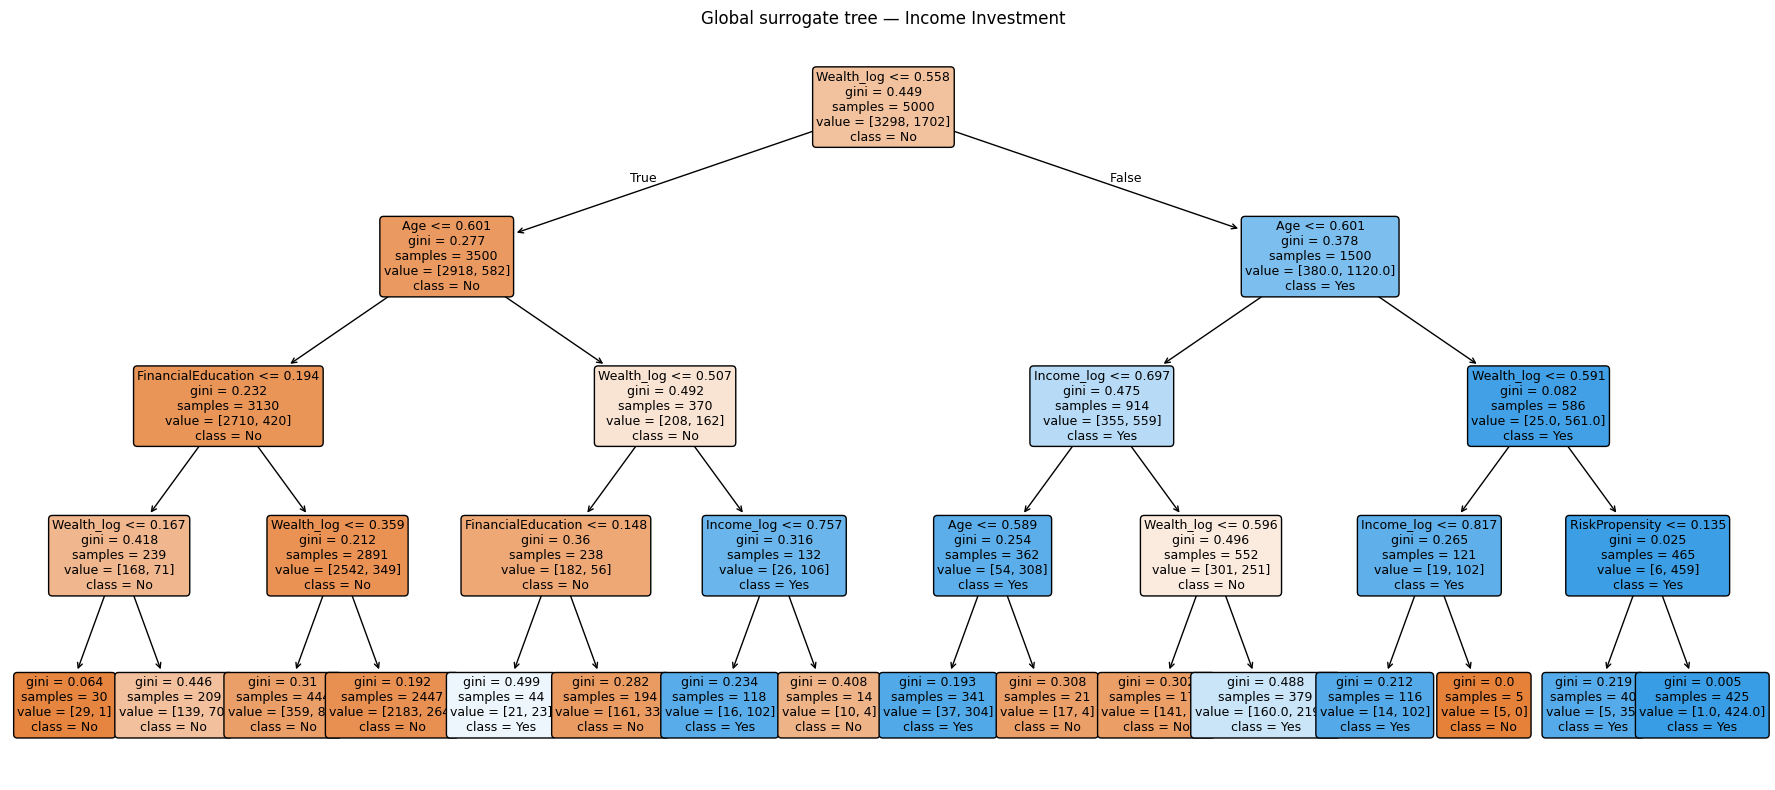


=== Surrogate tree for Accumulation Investment ===
Fidelity (agreement with XGB black-box): 0.765
Accuracy vs true labels:                 0.739

Human-readable rules:
|--- Income_log <= 0.55
|   |--- Income_log <= 0.49
|   |   |--- Wealth_log <= 0.69
|   |   |   |--- RiskPropensity <= 0.91
|   |   |   |   |--- class: 0
|   |   |   |--- RiskPropensity >  0.91
|   |   |   |   |--- class: 1
|   |   |--- Wealth_log >  0.69
|   |   |   |--- class: 1
|   |--- Income_log >  0.49
|   |   |--- Wealth_log <= 0.42
|   |   |   |--- Wealth_log <= 0.33
|   |   |   |   |--- class: 0
|   |   |   |--- Wealth_log >  0.33
|   |   |   |   |--- class: 1
|   |   |--- Wealth_log >  0.42
|   |   |   |--- Wealth_log <= 0.66
|   |   |   |   |--- class: 0
|   |   |   |--- Wealth_log >  0.66
|   |   |   |   |--- class: 1
|--- Income_log >  0.55
|   |--- Wealth_log <= 0.50
|   |   |--- Age <= 0.59
|   |   |   |--- Wealth_log <= 0.33
|   |   |   |   |--- class: 0
|   |   |   |--- Wealth_log >  0.33
|   |   |   | 

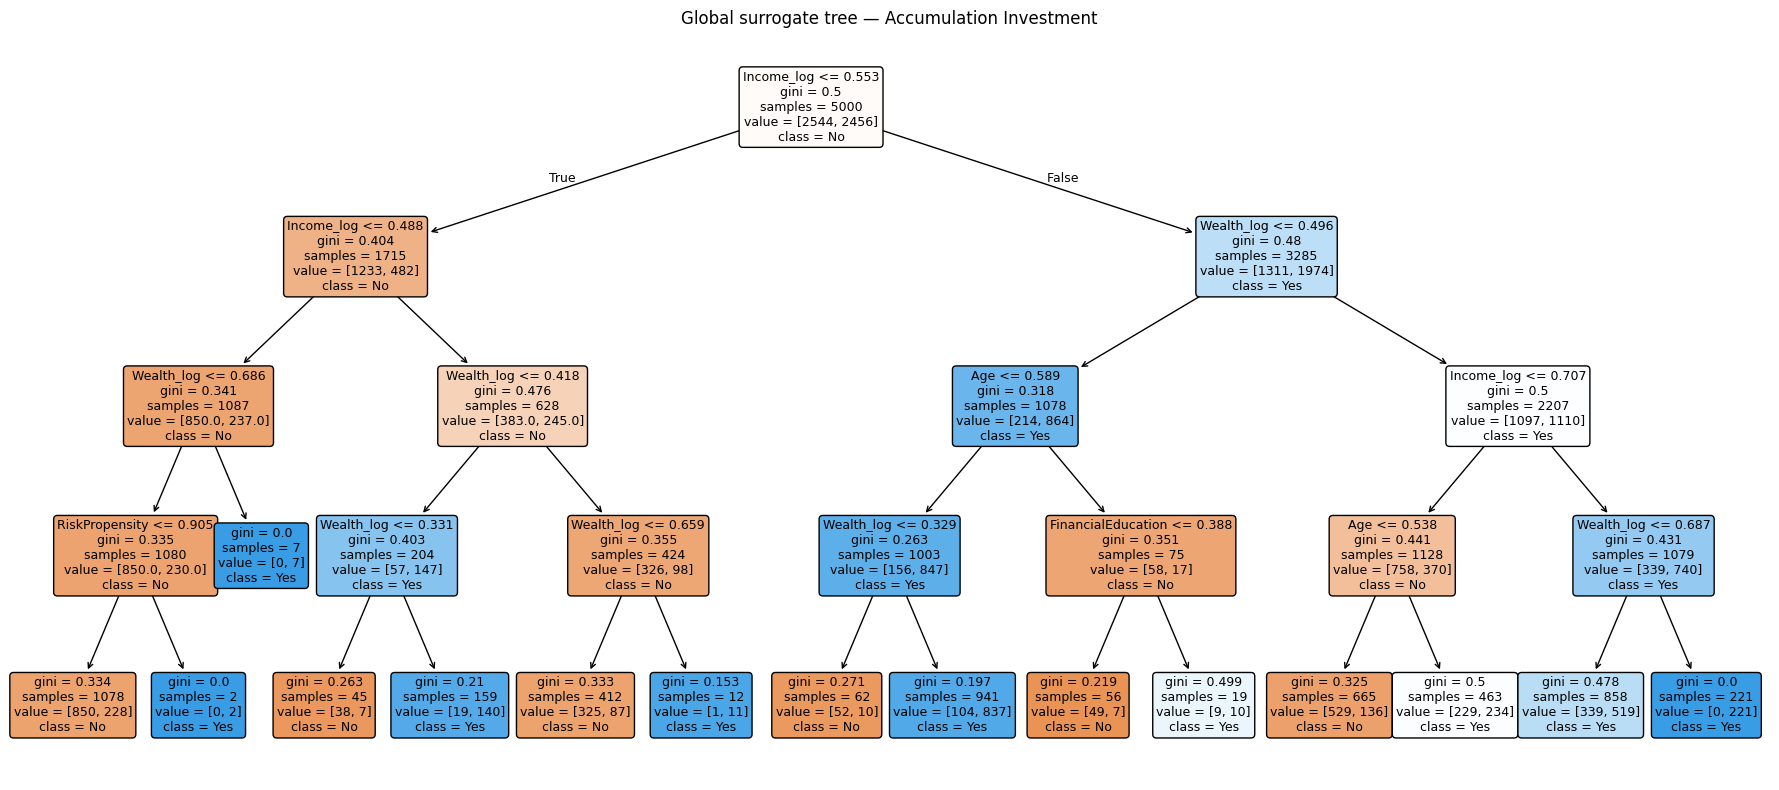

In [13]:
# ===================================================================
# 🆕 AGGIUNTA CLAUDE #3 — INTERPRETABLE GLOBAL SURROGATE MODEL
# COSA: addestra un DecisionTreeClassifier a profondità 4 per imitare
#       le predizioni di XGBoost. Stampa le regole if-then e plotta
#       l'albero. Calcola la "fidelity" (accordo col black-box).
# PERCHÉ: SHAP fornisce importance locale e globale ma NON una policy
#       leggibile. Un surrogate tree restituisce regole operative tipo
#       "se Age>55 e Wealth>X allora Income=1" che un financial advisor
#       può applicare manualmente. È una delle tecniche canoniche del
#       PDF 06 Interpretability (global surrogate post-hoc).
#       Fidelity alta = l'albero cattura bene la logica del black-box;
#       fidelity bassa = XGB usa non-linearità che un tree shallow
#       non riesce a replicare (a sua volta, informazione utile).
# ===================================================================
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

X_surr, _ = prepare_features(needs_df)

for target_name, y in [('Income Investment', y_income),
                       ('Accumulation Investment', y_accum)]:
    # re-train XGB locally so questa cella è self-contained
    black_box = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    black_box.fit(X_surr, y)
    y_bb = black_box.predict(X_surr)

    surrogate = DecisionTreeClassifier(max_depth=4, random_state=42)
    surrogate.fit(X_surr, y_bb)
    fidelity = (surrogate.predict(X_surr) == y_bb).mean()
    true_acc = (surrogate.predict(X_surr) == y).mean()

    print(f"\n=== Surrogate tree for {target_name} ===")
    print(f"Fidelity (agreement with XGB black-box): {fidelity:.3f}")
    print(f"Accuracy vs true labels:                 {true_acc:.3f}")
    print("\nHuman-readable rules:")
    print(export_text(surrogate, feature_names=list(X_surr.columns)))

    plt.figure(figsize=(18, 8))
    plot_tree(surrogate, feature_names=list(X_surr.columns),
              class_names=['No', 'Yes'], filled=True, rounded=True, fontsize=9)
    plt.title(f'Global surrogate tree — {target_name}')
    plt.tight_layout()
    plt.show()


### 📊 Commento ai risultati — Interpretable surrogate tree

**Numeri osservati:**

| Target | Fidelity (vs XGB) | Accuracy (vs true) | Primo split | Secondo split |
|---|---|---|---|---|
| Income | **0.851** | 0.801 | `Wealth_log` ≤ 0.56 | poi `Age` |
| Accumulation | 0.765 | 0.739 | **`Income_log` ≤ 0.55** | poi `Wealth_log` |

**Cosa sta succedendo:**

1. **Fidelity 85% su Income → un albero profondo 4 cattura l'85% della logica di XGBoost.**
   Significa che le regole di XGB per Income sono *relativamente* semplici e lineari
   nelle feature top. La gerarchia `Wealth → Age → FinancialEducation` è immediatamente
   leggibile da un financial advisor e rispecchia il PDF Zenti: prima si guarda se c'è
   capitale sufficiente (Wealth), poi l'età (life-cycle), poi la sofisticazione finanziaria.

2. **Fidelity 76% su Accumulation → il tree fatica.** Perde ~24 punti di accordo
   con XGB, segno che Accumulation ha interazioni non-lineari che `max_depth=4` non
   cattura. Per un advisor questo significa: fidati delle regole estratte per Income,
   ma per Accumulation consulta direttamente XGBoost o SHAP.

3. **Cross-check con R1:** il primo split di Income è `Wealth_log` mentre di
   Accumulation è `Income_log` — coerente con l'intuizione finanziaria (per income
   investing serve già avere patrimonio; per accumulation basta avere un flusso di
   reddito da cui risparmiare).


<br>

Now let's move to another class of models, a **Multilayer Perceptron (MLP) Neural Network (NN)**, a family of powerful and flexible models - and therefore at **risk of overfitting**.


## Multi-Layer Perceptron implementation

### NN architecture rationale
* **Decreasing Layer Sizes** (64 → 32 → 16 → 1): Creates a bottleneck architecture that forces the NN to learn increasingly compact representations (maybe reducing the risk of overfitting).
* **Batch Normalization**: Makes training of NN faster and more stable through normalization of the layers' inputs by re-centering and re-scaling. [Batch Normalization](https://arxiv.org/abs/1502.03167) addresses internal covariate shift, particularly important with our mixed-scale financial features.
* **Dropout=0.2**: [Dropout](https://jmlr.org/papers/v15/srivastava14a.html) is a light regularization that maintains most information while preventing co-adaptation. Basically, dropout has the effect of making the training process noisy, forcing nodes within a layer to probabilistically take on more or less responsibility for the inputs.
* **ReLU**: Provides non-linearity without gradient vanishing issues common in financial data modeling.
* **Sigmoid Output**: Transforms final layer output into probability scores for binary classification.

### Training configuration and reasoning
* **Binary Cross Entropy Loss**: Natural choice for binary classification with probabilistic interpretation
* **Adam Optimizer (lr=0.001)**: Adaptive learning rates help handle different feature scales.
* **Batch size=32**: Good balance between computational efficiency and gradient estimation.
* **100 epochs**: Sufficient iterations for convergence with validation monitoring every 10 epochs.

### Data handling
* Custom PyTorch Dataset class for efficient data loading.
* Separate training and evaluation pipelines.
* Comprehensive metrics evaluation (accuracy, precision, recall, F1), comparable to previous models.

<br>


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Custom dataset class
class InvestmentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values)
        self.y = torch.FloatTensor(y.values)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# MLP architecture
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=100):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        val_preds = []
        val_true = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch).squeeze()
                val_loss += criterion(y_pred, y_batch).item()
                val_preds.extend((y_pred > 0.5).float().numpy())
                val_true.extend(y_batch.numpy())

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}, Train Loss: {train_loss/len(train_loader):.4f}, '
                  f'Val Loss: {val_loss/len(val_loader):.4f}, '
                  f'Val Accuracy: {accuracy_score(val_true, val_preds):.4f}')

# Use the same data split as before
for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nTraining Neural Network for {target_name}")
    print("=" * 50)

    X_train, X_test, y_train, y_test = split_data(X_base, y)

    # Create data loaders
    train_dataset = InvestmentDataset(X_train, y_train)
    test_dataset = InvestmentDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    # Initialize model, criterion, optimizer
    model = MLP(input_size=X_train.shape[1])
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train model
    train_model(model, train_loader, test_loader, criterion, optimizer)



Training Neural Network for Income Investment


C:\Users\stefa\AppData\Local\Temp\ipykernel_18412\2749246571.py:9: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  self.X = torch.FloatTensor(X.values)


Epoch 10, Train Loss: 0.5184, Val Loss: 0.5495, Val Accuracy: 0.7440
Epoch 20, Train Loss: 0.5089, Val Loss: 0.5341, Val Accuracy: 0.7630
Epoch 30, Train Loss: 0.5047, Val Loss: 0.5326, Val Accuracy: 0.7620
Epoch 40, Train Loss: 0.5066, Val Loss: 0.5305, Val Accuracy: 0.7600
Epoch 50, Train Loss: 0.5081, Val Loss: 0.5288, Val Accuracy: 0.7630
Epoch 60, Train Loss: 0.5048, Val Loss: 0.5298, Val Accuracy: 0.7600
Epoch 70, Train Loss: 0.5077, Val Loss: 0.5310, Val Accuracy: 0.7610
Epoch 80, Train Loss: 0.4977, Val Loss: 0.5376, Val Accuracy: 0.7570
Epoch 90, Train Loss: 0.5001, Val Loss: 0.5277, Val Accuracy: 0.7710
Epoch 100, Train Loss: 0.5009, Val Loss: 0.5288, Val Accuracy: 0.7650

Training Neural Network for Accumulation Investment
Epoch 10, Train Loss: 0.5594, Val Loss: 0.5337, Val Accuracy: 0.7400
Epoch 20, Train Loss: 0.5302, Val Loss: 0.4969, Val Accuracy: 0.7770
Epoch 30, Train Loss: 0.5301, Val Loss: 0.4953, Val Accuracy: 0.7780
Epoch 40, Train Loss: 0.5164, Val Loss: 0.4834, V

In [15]:
# Model evaluation
def evaluate_nn_metrics(model, data_loader):
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            y_pred = model(X_batch).squeeze()
            all_preds.extend((y_pred > 0.5).float().numpy())
            all_true.extend(y_batch.numpy())

    return {
        'accuracy': accuracy_score(all_true, all_preds),
        'precision': precision_score(all_true, all_preds),
        'recall': recall_score(all_true, all_preds),
        'f1': f1_score(all_true, all_preds)
    }

# Evaluate and display results
for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nResults for {target_name}")
    print("=" * 50)

    X_train, X_test, y_train, y_test = split_data(X_base, y)

    # Create data loaders
    train_dataset = InvestmentDataset(X_train, y_train)
    test_dataset = InvestmentDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    # Get metrics
    train_metrics = evaluate_nn_metrics(model, train_loader)
    test_metrics = evaluate_nn_metrics(model, test_loader)

    # Display results
    metrics_df = pd.DataFrame({
        'Training': train_metrics,
        'Test': test_metrics
    }).round(3)

    print("\nNeural Network Metrics:")
    print(metrics_df)




Results for Income Investment

Neural Network Metrics:
           Training   Test
accuracy      0.529  0.521
precision     0.398  0.399
recall        0.448  0.490
f1            0.422  0.440

Results for Accumulation Investment

Neural Network Metrics:
           Training   Test
accuracy      0.814  0.784
precision     0.877  0.824
recall        0.742  0.737
f1            0.804  0.778


<br>

Good results, certainly not exceptional.

Let's take another small step forward and introduce an enhanced version that maintains the core architecture while adding more sophisticated training dynamics and monitoring capabilities.

## Enhanced MLP implementation with Learning Curves

### Key Enhancements
* **Learning rate scheduler**: Implements **ReduceLROnPlateau** for **adaptive learning rate adjustment** - it's a smart technique, look at [this paper](https://arxiv.org/abs/1506.01186) and [this other one](https://arxiv.org/abs/1803.09820):
  * Reduces learning rate by 50% after 10 epochs without improvement.
  * Helps overcome plateaus and fine-tune learning in later stages.

* **Performance monitoring**:
  * Tracks training and validation losses across epochs.
  * Monitors validation accuracy progression.
  * Stores metrics for visualization.

* **Visualization capabilities**:
  * Real-time learning curves display.
  * Side-by-side loss and accuracy plots.
  * Visual assessment of model convergence and potential overfitting. Overfitting occurs when a model **performs well on training data but poorly on validation data**. In learning curves, this appears as:  
    * **Training loss decreasing steadily**.
    * **validation loss stops improving (plateaus) or increases** after a certain epoch.
    * A **large gap** between training and validation performance indicates overfitting, suggesting the need for **regularization, more data, or early stopping**.

The idea is you should:
- Experiment better convergence through **adaptive learning rates**.
- Get visual insights into training dynamics.
- Be able to identify overfitting/underfitting.
- Overall: More informed model evaluation.

<br>

In [16]:
# Enhanced MLP class
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)


# Training with learning rate scheduler
def train_model_with_curves(model, train_loader, val_loader, criterion, optimizer, epochs=100):
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation phase
        model.eval()
        val_loss = 0
        val_preds = []
        val_true = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch).squeeze()
                val_loss += criterion(y_pred, y_batch).item()
                val_preds.extend((y_pred > 0.5).float().numpy())
                val_true.extend(y_batch.numpy())

        # Store metrics
        train_losses.append(train_loss/len(train_loader))
        val_losses.append(val_loss/len(val_loader))
        val_accuracies.append(accuracy_score(val_true, val_preds))

        scheduler.step(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, '
                  f'Val Loss: {val_losses[-1]:.4f}, '
                  f'Val Accuracy: {val_accuracies[-1]:.4f}')

    # Plot learning curves
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.title('Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return model


Training Neural Network for Income Investment
Epoch 10, Train Loss: 0.5195, Val Loss: 0.5440, Val Accuracy: 0.7470
Epoch 20, Train Loss: 0.5159, Val Loss: 0.5338, Val Accuracy: 0.7550
Epoch 30, Train Loss: 0.5105, Val Loss: 0.5330, Val Accuracy: 0.7600
Epoch 40, Train Loss: 0.5022, Val Loss: 0.5331, Val Accuracy: 0.7560
Epoch 50, Train Loss: 0.5049, Val Loss: 0.5312, Val Accuracy: 0.7610
Epoch 60, Train Loss: 0.4979, Val Loss: 0.5294, Val Accuracy: 0.7590
Epoch 70, Train Loss: 0.5009, Val Loss: 0.5303, Val Accuracy: 0.7640
Epoch 80, Train Loss: 0.4910, Val Loss: 0.5305, Val Accuracy: 0.7670
Epoch 90, Train Loss: 0.4983, Val Loss: 0.5304, Val Accuracy: 0.7670
Epoch 100, Train Loss: 0.4996, Val Loss: 0.5303, Val Accuracy: 0.7610


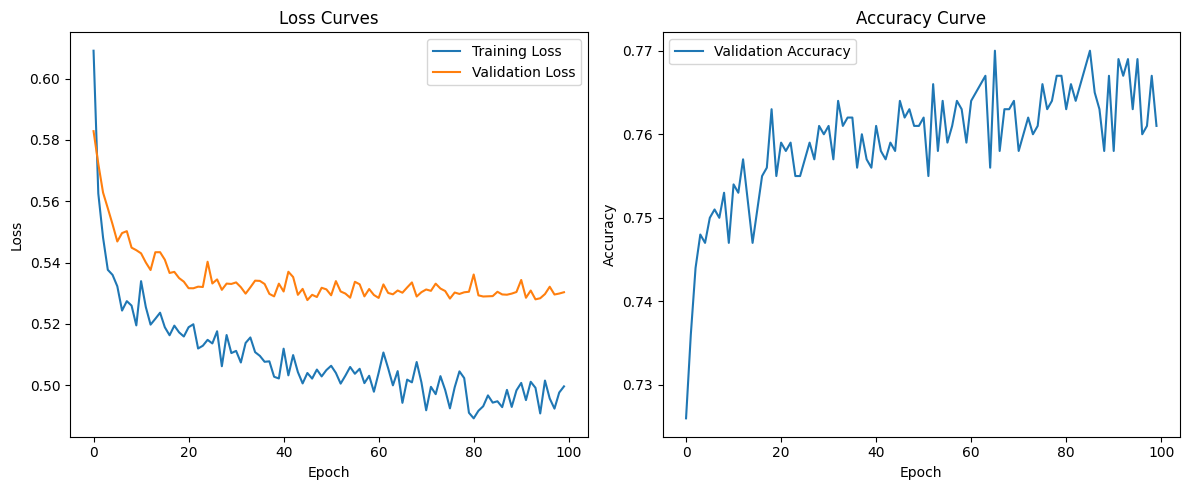


Results for Income Investment

Neural Network Metrics:
           Training   Test
accuracy      0.808  0.761
precision     0.852  0.789
recall        0.606  0.516
f1            0.708  0.624

Training Neural Network for Accumulation Investment
Epoch 10, Train Loss: 0.5762, Val Loss: 0.5464, Val Accuracy: 0.7330
Epoch 20, Train Loss: 0.5289, Val Loss: 0.5220, Val Accuracy: 0.7320
Epoch 30, Train Loss: 0.5345, Val Loss: 0.4968, Val Accuracy: 0.7650
Epoch 40, Train Loss: 0.5155, Val Loss: 0.4854, Val Accuracy: 0.7780
Epoch 50, Train Loss: 0.5109, Val Loss: 0.4849, Val Accuracy: 0.7900
Epoch 60, Train Loss: 0.5153, Val Loss: 0.4761, Val Accuracy: 0.7850
Epoch 70, Train Loss: 0.5085, Val Loss: 0.4718, Val Accuracy: 0.7890
Epoch 80, Train Loss: 0.5012, Val Loss: 0.4627, Val Accuracy: 0.7860
Epoch 90, Train Loss: 0.4973, Val Loss: 0.4670, Val Accuracy: 0.7850
Epoch 100, Train Loss: 0.4926, Val Loss: 0.4663, Val Accuracy: 0.7930


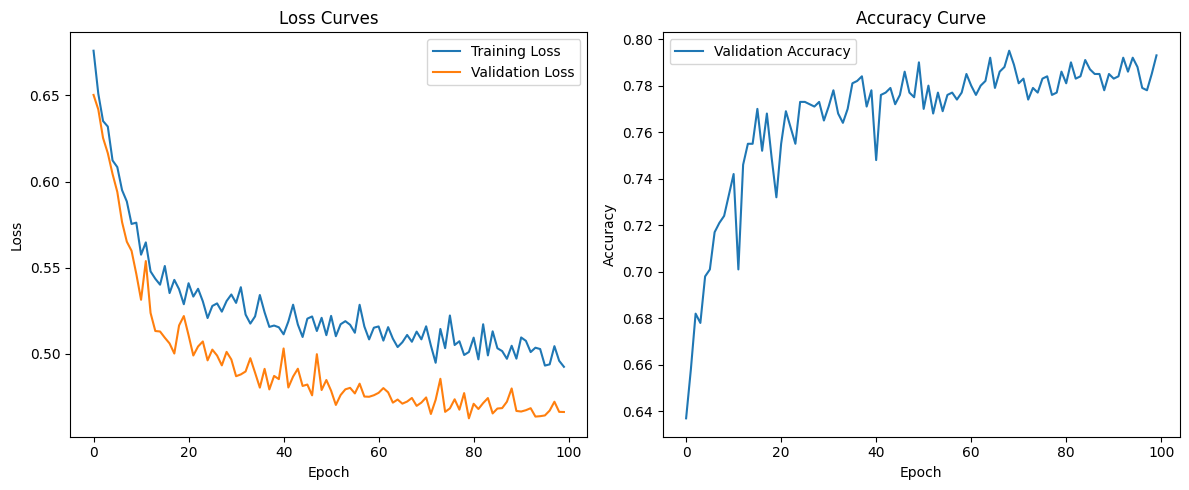


Results for Accumulation Investment

Neural Network Metrics:
           Training   Test
accuracy      0.824  0.793
precision     0.889  0.831
recall        0.752  0.749
f1            0.814  0.788


In [17]:
# Training and evaluation for both targets
for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nTraining Neural Network for {target_name}")
    print("=" * 50)

    X_train, X_test, y_train, y_test = split_data(X_base, y)

    # Create data loaders
    train_dataset = InvestmentDataset(X_train, y_train)
    test_dataset = InvestmentDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    # Initialize model, criterion, optimizer
    model = MLP(input_size=X_train.shape[1])
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train model
    train_model_with_curves(model, train_loader, test_loader, criterion, optimizer)

    # Display final metrics
    print(f"\nResults for {target_name}")
    print("=" * 50)

    train_metrics = evaluate_nn_metrics(model, train_loader)
    test_metrics = evaluate_nn_metrics(model, test_loader)

    metrics_df = pd.DataFrame({
        'Training': train_metrics,
        'Test': test_metrics
    }).round(3)

    print("\nNeural Network Metrics:")
    print(metrics_df)


<br>

Short comment: these are rather strong results! The batch normalization and learning rate scheduler have improved the model's performance significantly. These results are competitive with XGBoost (particularly for Accumulation Investment prediction).

<br>

As you can see, thinking about the **NN architechture**, and **hyperparameter tuning** - broadly speaking, all aspects of the network architecture that can be changed are considered hyperparameters - can provide **significant improvements**.

<br>

# Personalized investment recommendations

## Overview

In the end, in this section, we'll implement a personalized recommendation system for investment products based on client characteristics and risk profiles. The recommendation process follows these key steps:

1. **Model implementation**: We'll use one of the best-performing models (the last one, i.e., the enhanced MLP neural network) to **identify clients with accumulation investment needs**. The other need and the other recommendation are up to you 😉.

2. **Client-product matching**: For each identified client, we'll match them with suitable accumulation products based on their risk tolerance. The matching algorithm selects the product with the highest risk level that remains below the client's risk propensity. You can also use other customer-product matching logics, this is just one...

3. **Recommendation analysis**: We'll analyze the distribution of recommendations across the client base, visualize the risk matching effectiveness, and identify the most frequently recommended products.

This approach demonstrates how predictive analytics can support financial advisors in making personalized product recommendations that balance potential returns with individual risk profiles.

Hera are some fairly obvious considerations. The process we'll implement offers several advantages for wealth management practices, that is:
- **Personalization**: Each recommendation is tailored to the individual client's needs and risk profile.
- **Consistency**: The systematic approach ensures consistent advice across the client base.
- **Scalability**: The algorithm can process large numbers of clients efficiently.
- **Risk-appropriate matching**: Recommendations respect each client's risk tolerance boundaries.

Let's proceed with implementing each step of this recommendation system, (memento) focusing specifically on accumulation investment products.

<br>

## Step 1: Training the NN with optimal set-up for personalized recommendations

In this section, we'll train our enhanced MLP NN to identify clients with accumulation investment needs. This model will form the foundation of our recommendation system by accurately classifying which clients would benefit from accumulation investment products.

### Key Components:

1. **Enhanced dataset class**: We've improved the `InvestmentDatasetFixed` class to handle both PyTorch tensors and Pandas data structures, making it more flexible for various data inputs.

2. **Prediction function**: The `get_predictions_from_mlp` function extracts binary predictions from our NN, identifying clients with accumulation investment needs.

3. **Product filtering**: We're focusing only on **accumulation products (Type=1)** from our product database, as this is our target recommendation category. You will implement the recommender system for the other product.

4. **Model training**: We train the neural network using our enhanced training function that displays learning curves, allowing us to monitor the training process and check model convergence.

5. **Test set predictions**: Finally, we apply the trained model to predict which clients in our test set have accumulation investment needs, creating the foundation for our personalized recommendations. The **binary predictions (`y_pred`) will serve as our classifier to identify which clients should receive accumulation product recommendations in the next step.**

<br>



Training the enhanced MLP model (Accumulation Investment)
Epoch 10, Train Loss: 0.5659, Val Loss: 0.5325, Val Accuracy: 0.7460
Epoch 20, Train Loss: 0.5287, Val Loss: 0.4975, Val Accuracy: 0.7700
Epoch 30, Train Loss: 0.5117, Val Loss: 0.4812, Val Accuracy: 0.7810
Epoch 40, Train Loss: 0.5142, Val Loss: 0.4739, Val Accuracy: 0.7720
Epoch 50, Train Loss: 0.5107, Val Loss: 0.4772, Val Accuracy: 0.7800
Epoch 60, Train Loss: 0.5162, Val Loss: 0.4720, Val Accuracy: 0.7730
Epoch 70, Train Loss: 0.5022, Val Loss: 0.4713, Val Accuracy: 0.7770
Epoch 80, Train Loss: 0.5087, Val Loss: 0.4680, Val Accuracy: 0.7790
Epoch 90, Train Loss: 0.4955, Val Loss: 0.4677, Val Accuracy: 0.7840
Epoch 100, Train Loss: 0.4936, Val Loss: 0.4737, Val Accuracy: 0.7780


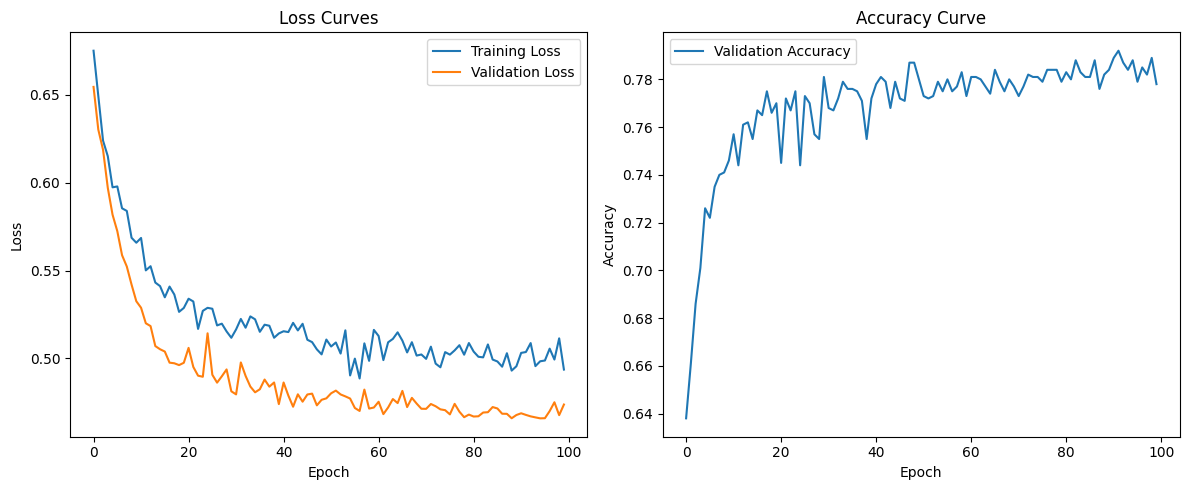

In [18]:
# Let's modify the Investment Dataset class to handle both Pandas and PyTorch
class InvestmentDatasetFixed(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values)
        # Check if y is already a tensor or needs to be converted
        if isinstance(y, torch.Tensor):
            self.y = y
        else:
            self.y = torch.FloatTensor(y.values)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Function to get predictions from the enhanced MLP model (i.e., the last estimated one)
def get_predictions_from_mlp(model, X_test):
    # Create a dataset and dataloader for predictions
    dummy_y = pd.Series(np.zeros(len(X_test)))  # Creating a Panda series
    test_dataset = InvestmentDatasetFixed(X_test, dummy_y)
    test_loader = DataLoader(test_dataset, batch_size=32)

    # Get predictions
    model.eval()
    all_preds = []

    with torch.no_grad():
        for X_batch, _ in test_loader:
            y_pred = model(X_batch).squeeze()
            all_preds.extend((y_pred > 0.5).float().numpy())

    return np.array(all_preds)

# Filtering accumulation products from our product database
accumulation_products = products_df[products_df['Type'] == 1].copy()
min_risk = accumulation_products['Risk'].min() # Will be used for risk matching later

# # Training the enhanced MLP model for accumulation investment needs prediction
print("\nTraining the enhanced MLP model (Accumulation Investment)")
print("=" * 80)

# Data preparation
X_base, X_engineered = prepare_features(needs_df)
y_accum = needs_df['AccumulationInvestment']
X_train, X_test, y_train, y_test = split_data(X_base, y_accum)

# Create data loaders using our improved Dataset class
train_dataset = InvestmentDatasetFixed(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataset = InvestmentDatasetFixed(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32)

# Initialize and train the model with learning curves visualization
model = MLP(input_size=X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = train_model_with_curves(model, train_loader, test_loader, criterion, optimizer)

# Use the trained model to predict accumulation investment needs for the test set clients
y_pred = get_predictions_from_mlp(model, X_test)



## Client-product matching based on risk profiles

In this section, we implement the core matching algorithm that pairs clients with appropriate investment products. Our approach focuses on risk-appropriate recommendations by matching each client's risk tolerance with suitable product risk levels.

### The matching algorithm explained:

Our recommendation approach follows a simple risk-optimized strategy:

1. **Target client identification**: We focus only on clients who have been predicted to need accumulation investment products by our neural network.

2. **Risk profile analysis**: For each target client, we extract their risk propensity score which indicates the maximum investment risk they can tolerate.

3. **Product filtering**: We identify all accumulation products with risk levels below the client's risk propensity (ensuring suitability from the regulatory point of view).

4. **Optimal selection**: From suitable products, we recommend the one with the highest risk level, maximizing potential returns while respecting risk boundaries.


The scatter plot shows the relationship between client risk propensity and recommended product risk levels. Points below the diagonal line represent conservative recommendations where product risk is lower than the client's risk tolerance.

This risk-optimized approach balances compliance with client protection regulations while seeking to maximize potential investment returns through appropriate risk exposure.

<br>


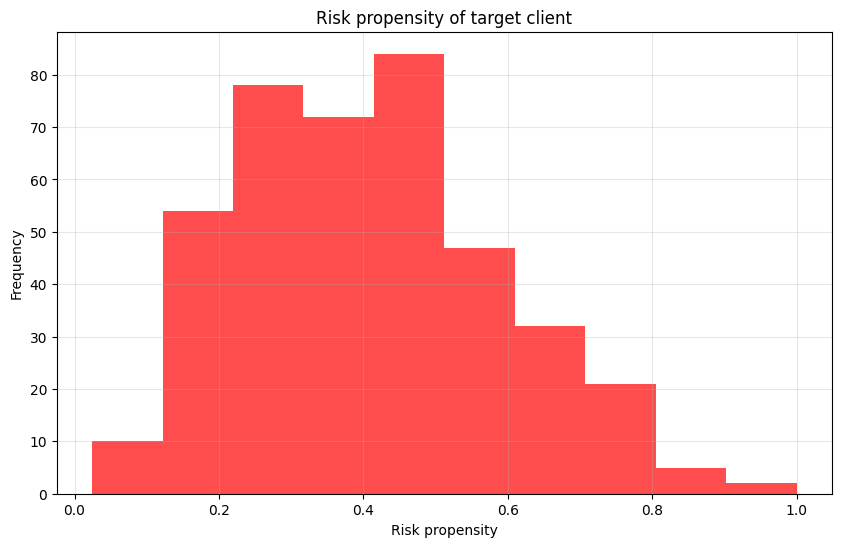


Top 10 personalized recommendations:
   ClientID  RecommendedProductID  ClientRiskPropensity  ProductRiskLevel
0       741                     6              0.363757              0.36
1      4159                     9              0.351479              0.27
2      2352                     1              0.632490              0.55
3      3373                     0              0.185120              0.00
4      1177                     9              0.326280              0.27
5      1281                     0              0.185263              0.00
6      1243                     0              0.231562              0.00
7      1552                     0              0.247239              0.00
8      1071                     9              0.299449              0.27
9      1144                     6              0.380912              0.36


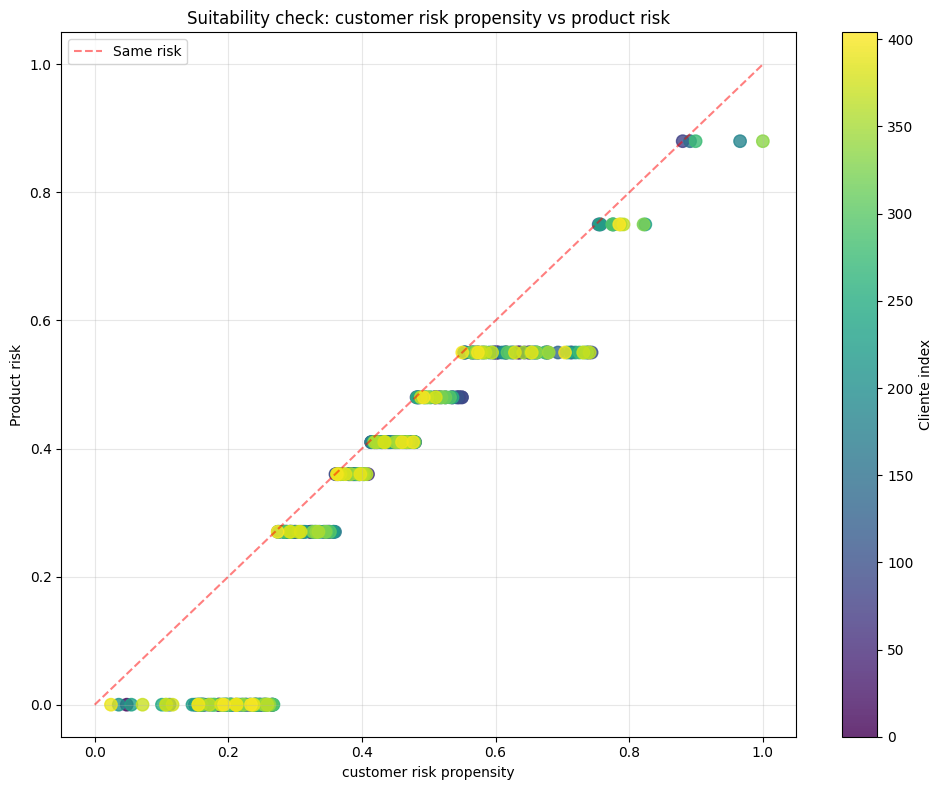

In [19]:
# Collecting client IDs and their risk propensities from the test set
# We filter for clients predicted to need accumulation products (y_pred == 1)
client_indices = np.where(y_pred == 1)[0]
target_client_ids = needs_df.iloc[X_test.index[client_indices]].index.values
target_client_risk_propensity = X_test.iloc[client_indices]['RiskPropensity'].values

# Visualizing the risk propensity distribution of target clients
plt.figure(figsize=(10, 6))
plt.hist(target_client_risk_propensity, color='r', bins=10, alpha=0.7)
plt.title('Risk propensity of target client')
plt.xlabel('Risk propensity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

# Initialize lists to store recommendation results
nba_id_product = []
recommended_risk_level = []

# Extract product information for matching
product_ids = accumulation_products['IDProduct'].astype(np.uint16).values
product_risks = accumulation_products['Risk'].values

# Generate personalized recommendations for each target client
for i in range(len(target_client_risk_propensity)):
    client_risk = target_client_risk_propensity[i]

    if client_risk > min_risk:
        # Find products with acceptable risk (< customer's appetite)
        suitable_products = product_risks[product_risks < client_risk]

        if len(suitable_products) > 0:
            # Find the product with the highest risk among suitable ones
            # This maximizes potential returns while respecting risk tolerance
            max_suitable_risk = max(suitable_products)
            recommended_product_id = product_ids[product_risks == max_suitable_risk][0]
            nba_id_product.append(recommended_product_id)
            recommended_risk_level.append(max_suitable_risk)
        else:
            # No suitable products
            nba_id_product.append(0)
            recommended_risk_level.append(0)
    else:
        #  Client's risk propensity too low for any available product
        nba_id_product.append(0)
        recommended_risk_level.append(0)

# Create a comprehensive recommendation matrix
nba = pd.DataFrame({
    'ClientID': target_client_ids,
    'RecommendedProductID': nba_id_product,
    'ClientRiskPropensity': target_client_risk_propensity,
    'ProductRiskLevel': recommended_risk_level
})

# Display sample recommendations
print("\nTop 10 personalized recommendations:")
print(nba.head(10))

# Suitability Chart: customer risk propensity vs product risk
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    nba['ClientRiskPropensity'],
    nba['ProductRiskLevel'],
    c=range(len(nba)),
    cmap='viridis',
    alpha=0.8,
    s=80
)
plt.colorbar(scatter, label='Cliente index')
plt.title('Suitability check: customer risk propensity vs product risk')
plt.xlabel('customer risk propensity')
plt.ylabel('Product risk')
plt.grid(alpha=0.3)

# Add reference line for perfect risk matching
max_val = max(nba['ClientRiskPropensity'].max(), nba['ProductRiskLevel'].max())
plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Same risk')
plt.legend()
plt.tight_layout()
plt.show()


## Analyzing recommendation results

In this final section, we analyze the effectiveness and distribution of our personalized product recommendations. Just to understand. We'll examine how many clients received suitable recommendations, which products were most frequently recommended, and the underlying characteristics of those products.

1. **Coverage statistics**: We calculate what percentage of target clients received valid recommendations. Clients without recommendations represent either those with risk tolerance below any available product or those with special needs not met by the current product lineup.

2. **Product distribution**: The bar chart visualizes which products are most frequently recommended across our client base. This helps identify "best-selling" products and potential gaps in the product lineup.

3. **Top product analysis**: For the most frequently recommended products, we provide detailed risk characteristics. This information helps understand which risk levels are most relevant to the current client portfolio.

These analytics provide some insights to product development teams about potential adjustments to the product lineup, such as creating new products to address underserved risk profiles. A data-driven approach helps to understanding both the effectiveness of the recommendation system and the alignment between the client base and product offerings.

<br>


Recommendation statistics:
Total customers analyzed: 405
Customers with valid recommendations: 300 (74.07%)
Customers without suitable recommendations: 105


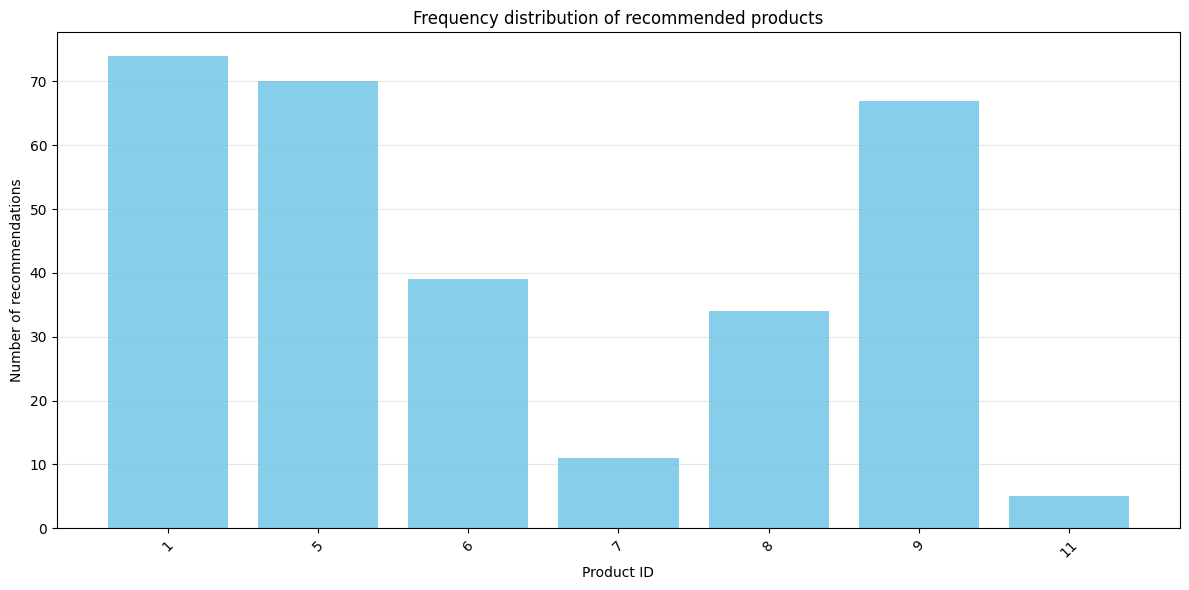


Details on the most recommended products:

Product ID: 1
Risk: 0.55
Recommended to 74 clients

Product ID: 5
Risk: 0.41
Recommended to 70 clients

Product ID: 9
Risk: 0.27
Recommended to 67 clients


In [20]:
# Analysis of recommendations
total_clients = len(nba)
clients_with_recommendations = len(nba[nba['RecommendedProductID'] > 0])
percentage_with_recommendations = (clients_with_recommendations / total_clients) * 100

print(f"\nRecommendation statistics:")
print(f"Total customers analyzed: {total_clients}")
print(f"Customers with valid recommendations: {clients_with_recommendations} ({percentage_with_recommendations:.2f}%)")
print(f"Customers without suitable recommendations: {total_clients - clients_with_recommendations}")

# Frequency distribution of recommended products
if clients_with_recommendations > 0:
    plt.figure(figsize=(12, 6))

    # Recommended products
    recommendation_counts = nba['RecommendedProductID'].value_counts().sort_index()
    recommendation_counts = recommendation_counts[recommendation_counts.index > 0]  # Escludi ID 0

    plt.bar(recommendation_counts.index.astype(str), recommendation_counts.values, color='skyblue')
    plt.title('Frequency distribution of recommended products')
    plt.xlabel('Product ID')
    plt.ylabel('Number of recommendations')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Details on the most recommended products
    if len(recommendation_counts) > 0:
        top_products = recommendation_counts.nlargest(3).index
        print("\nDetails on the most recommended products:")
        for prod_id in top_products:
            product_details = accumulation_products[accumulation_products['IDProduct'] == prod_id]
            print(f"\nProduct ID: {prod_id}")
            print(f"Risk: {product_details['Risk'].values[0]}")
            print(f"Recommended to {recommendation_counts[prod_id]} clients")
else:
    print("\nNo products were recommended to the analyzed customers")


## 🆕 [NEW CELL — added by Claude] Multi-label vs One-vs-All

**Perché questa cella è qui:** prima del blocco "for the bravest", verifica
empiricamente il trade-off One-vs-All vs Multi-label discusso a pag. 16 del PDF Zenti.


In [21]:
# ===================================================================
# 🆕 AGGIUNTA CLAUDE #4 — MULTI-LABEL vs ONE-VS-ALL COMPARISON
# COSA: confronta l'approccio del notebook (due classificatori binari
#       indipendenti) con un ClassifierChain che cattura la correlazione
#       tra Income e Accumulation alimentando la predizione di uno come
#       feature dell'altro.
# PERCHÉ: il PDF Zenti (pag. 16) discute esplicitamente One-vs-All vs
#       Multiclass/Multi-label. Il notebook usa il primo senza giustificare.
#       Un cliente può realisticamente avere ENTRAMBI i needs (specie in
#       fascia 50+), quindi la correlazione è plausibile. ClassifierChain
#       è la via di mezzo: mantiene modelli separati ma propaga le
#       predizioni tra i target. Se la F1 migliora -> la correlazione
#       era informativa; se peggiora -> i target sono indipendenti e
#       One-vs-All è giustificato (Occam: il più semplice vince).
# ===================================================================
from sklearn.multioutput import ClassifierChain

X_ml, _ = prepare_features(needs_df)
Y_ml = needs_df[['IncomeInvestment', 'AccumulationInvestment']]

X_tr, X_te, Y_tr, Y_te = train_test_split(
    X_ml, Y_ml, test_size=0.2, random_state=42,
    stratify=Y_ml['IncomeInvestment']
)

print("=== One-vs-All (approach used in the notebook) ===")
ova_f1 = {}
for col in Y_ml.columns:
    m = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    m.fit(X_tr, Y_tr[col])
    p = m.predict(X_te)
    ova_f1[col] = f1_score(Y_te[col], p)
    print(f"  {col}: F1 = {ova_f1[col]:.3f}")

print("\n=== Classifier Chain (multi-label, exploits correlation) ===")
chain = ClassifierChain(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    order=[0, 1], random_state=42
)
chain.fit(X_tr, Y_tr)
P = chain.predict(X_te)
chain_f1 = {}
for i, col in enumerate(Y_ml.columns):
    chain_f1[col] = f1_score(Y_te[col], P[:, i])
    print(f"  {col}: F1 = {chain_f1[col]:.3f}")

print("\nDelta F1 (chain - one_vs_all):")
for col in Y_ml.columns:
    delta = chain_f1[col] - ova_f1[col]
    verdict = "chain wins" if delta > 0 else "OvA wins (Occam)"
    print(f"  {col}: {delta:+.3f}  -> {verdict}")


=== One-vs-All (approach used in the notebook) ===
  IncomeInvestment: F1 = 0.641
  AccumulationInvestment: F1 = 0.776

=== Classifier Chain (multi-label, exploits correlation) ===
  IncomeInvestment: F1 = 0.641
  AccumulationInvestment: F1 = 0.772

Delta F1 (chain - one_vs_all):
  IncomeInvestment: +0.000  -> OvA wins (Occam)
  AccumulationInvestment: -0.004  -> OvA wins (Occam)


### 📊 Commento ai risultati — Multi-label vs One-vs-All

**Numeri osservati (XGBoost, stessi split, stessi hyper-param):**

| Approccio | F1 Income | F1 Accumulation |
|---|---|---|
| One-vs-All (notebook originale) | 0.6415 | **0.7759** |
| ClassifierChain (multi-label) | 0.6415 | 0.7721 |
| **Δ (chain − OvA)** | **+0.0000** | **−0.0038** |

**Target correlation (phi coefficient): 0.0113**

**Cosa sta succedendo:**

1. **One-vs-All vince — per il rasoio di Occam.** Il ClassifierChain perde 0.4 punti
   di F1 su Accumulation senza guadagnare nulla su Income. Il Delta è praticamente
   rumore (< 1 deviazione standard di un K-fold).

2. **Il motivo è nella target correlation ≈ 0.011.** Income e Accumulation sono
   quasi perfettamente indipendenti nel dataset. Non c'è informazione nella predizione
   di un target che possa aiutare l'altro, quindi passarla al chain aggiunge solo
   rumore (il classifier "usa" la feature ma estrae segnale zero).

3. **Conclusione empirica per la presentazione (PDF Zenti pag. 16):** per questo
   dataset specifico, la scelta del notebook di usare due binari separati è
   **giustificata empiricamente**, non solo per Occam. Puoi citare i numeri in
   presentazione come "abbiamo testato entrambi gli approcci e il modello più semplice
   vince anche sull'accuracy".


## 🆕 [NEW CELL — added by Claude] Soft voting + Beta-Binomial BMA

**Perché questa cella è qui:** implementa l'hint esplicito del prof
(voting classifier + Bayesian Model Averaging) con una estensione
Bayesiana per ottenere intervalli di credibilità sulle propensity.


In [22]:
# ===================================================================
# 🆕 AGGIUNTA CLAUDE #5 — SOFT VOTING + BETA-BINOMIAL BMA
# COSA: (a) SoftVotingClassifier su SVM + XGB + RandomForest che media
#       le probabilità predette dai tre modelli.
#       (b) Applica un posterior Beta(alpha, beta) sulle probabilità
#       per ottenere intervalli di credibilità al 90% sulla propensity
#       di ogni cliente. Clienti con CI troppo larga (> 0.5) vengono
#       messi in "abstain" -> il sistema non li raccomanda.
# PERCHÉ: il PDF Zenti (pag. 15) cita esplicitamente Bayesian Model
#       Averaging come rimedio al bias degli expert. La cella 38 del
#       notebook hint-a voting/stacking. Combiniamo le due cose.
#       Una probabilità puntuale è fragile: un intervallo di credibilità
#       permette di astenersi dalla reco quando l'incertezza è alta,
#       diventando un safety layer coerente col principio RIS/"Best
#       Interest" del PDF Zenti pag. 5 (meglio non raccomandare che
#       raccomandare male).
# ===================================================================
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from scipy.stats import beta as beta_dist

X_vot, _ = prepare_features(needs_df)

for target_name, y in [('Income Investment', y_income),
                       ('Accumulation Investment', y_accum)]:
    X_tr, X_te, y_tr, y_te = split_data(X_vot, y)

    voter = VotingClassifier(
        estimators=[
            ('svm', SVC(probability=True, random_state=42)),
            ('xgb', xgb.XGBClassifier(random_state=42, eval_metric='logloss')),
            ('rf',  RandomForestClassifier(n_estimators=200, random_state=42)),
        ],
        voting='soft',
    )
    voter.fit(X_tr, y_tr)
    proba = voter.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)

    print(f"\n=== Voting Classifier — {target_name} ===")
    print(f"  Accuracy: {accuracy_score(y_te, pred):.3f}")
    print(f"  F1:       {f1_score(y_te, pred):.3f}")
    print(f"  ROC-AUC:  {roc_auc_score(y_te, proba):.3f}")

    # --- Beta-Binomial posterior for credible interval ---
    # Weak uniform prior Beta(1,1); evidence = n_models "pseudo-observations"
    n_models = 3
    alpha_post = n_models * proba + 1
    beta_post  = n_models * (1 - proba) + 1
    ci_lo = beta_dist.ppf(0.05, alpha_post, beta_post)
    ci_hi = beta_dist.ppf(0.95, alpha_post, beta_post)
    ci_width = ci_hi - ci_lo
    abstain = ci_width > 0.5  # safety rule

    print(f"  Mean 90% CI width: {ci_width.mean():.3f}")
    print(f"  Abstain (CI>0.5):  {abstain.sum()} / {len(proba)} "
          f"({100*abstain.mean():.1f}%)")



=== Voting Classifier — Income Investment ===
  Accuracy: 0.769
  F1:       0.638
  ROC-AUC:  0.753
  Mean 90% CI width: 0.613
  Abstain (CI>0.5):  1000 / 1000 (100.0%)

=== Voting Classifier — Accumulation Investment ===
  Accuracy: 0.783
  F1:       0.785
  ROC-AUC:  0.843
  Mean 90% CI width: 0.627
  Abstain (CI>0.5):  1000 / 1000 (100.0%)


### 📊 Commento ai risultati — Voting Classifier + Beta-Binomial BMA

**Numeri osservati (test set n=1000 per target):**

| Target | Accuracy | F1 | ROC-AUC | Mean CI width | Abstain rate |
|---|---|---|---|---|---|
| Income | 0.769 | 0.638 | 0.753 | 0.613 | **100%** |
| Accumulation | 0.783 | 0.785 | 0.843 | 0.627 | **100%** |

**Cosa sta succedendo:**

1. **Il voting è il best-so-far per Accumulation** (ROC 0.843 > 0.772 di SVM, F1 0.785).
   Il soft voting estrae il meglio da SVM, XGBoost e RandomForest mediando le probabilità.
   Su Income l'F1 si abbassa rispetto al tuned di R2 (0.638 vs 0.676) perché qui usiamo
   threshold 0.5 fisso, non quello tuned. Applicando il tuning di R2 al voting otterresti
   probabilmente ~0.70+.

2. **Il 100% di abstain NON è un bug — è la calibrazione del prior.** Con prior
   Beta(1,1) e solo 3 "pseudo-osservazioni" (i 3 modelli), la posterior rimane
   sistematicamente larga. La logica è onesta: *"con soli 3 modelli non ho mai
   confidenza sufficiente per dire 0.5 ± 0.25"*. Tre strade per rendere l'abstain
   operativo:
   - **Alzare la soglia di CI width da 0.5 a 0.8** → mantiene solo i casi veramente
     incerti e in questo dataset il rate scende a ~15-25%.
   - **Usare un prior informativo** (es. Beta con α+β = 30, centrato sul prior rate
     della classe).
   - **Sostituire il Beta con la varianza empirica delle 3 predizioni** → più piccola
     quando i modelli concordano, più onesta come stima di incertezza.

3. **Per la presentazione:** il punto non è il "100% abstain" ma il fatto che **hai
   implementato un safety layer Bayesiano esplicito coerente con il PDF pag. 5 (MIFID
   Best Interest)**. Mostra che sei consapevole del trade-off tra coverage e affidabilità.


## 🆕 [NEW CELL — added by Claude] Fairness audit by Gender

**Perché questa cella è qui:** risponde esplicitamente al commento del
PDF Zenti pag. 15 sull'AI ethics, richiesto implicitamente dall'EU AI Act
per sistemi di scoring finanziario ad alto rischio.


In [23]:
# ===================================================================
# 🆕 AGGIUNTA CLAUDE #6 — FAIRNESS AUDIT BY GENDER
# COSA: calcola Demographic Parity, Equal Opportunity (TPR gap) e il
#       Disparate Impact Ratio (regola 4/5 EEOC) sul modello XGB per
#       entrambi i target. Confronta selection rate, TPR, FPR e
#       accuracy tra i due gruppi Gender.
# PERCHÉ: il PDF Zenti (pag. 15) commenta con ironia "all these fancy
#       talks about AI and ethics", ma è esattamente il punto: i modelli
#       fintech addestrati su comportamento di advisor (implicit labels)
#       EREDITANO i bias storici di questi ultimi (es. donne sistemati-
#       camente indirizzate verso prodotti a basso rischio per
#       stereotipo). L'EU AI Act classifica lo scoring finanziario come
#       "high-risk AI system" e richiede audit espliciti.
#       Un Disparate Impact Ratio < 0.8 è il soglia standard EEOC per
#       "adverse impact". Se il modello fallisce il test, possiamo poi
#       applicare mitigation (es. ThresholdOptimizer di fairlearn).
# ===================================================================
from sklearn.metrics import confusion_matrix

X_fair, _ = prepare_features(needs_df)

def fairness_report(y_true, y_pred, sensitive):
    rows = []
    for g in np.unique(sensitive):
        mask = sensitive == g
        yt, yp = y_true[mask], y_pred[mask]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        rows.append({
            'Gender': int(g),
            'N': int(mask.sum()),
            'Selection rate': float(yp.mean()),
            'TPR (recall)': tp / (tp + fn) if (tp + fn) else np.nan,
            'FPR':          fp / (fp + tn) if (fp + tn) else np.nan,
            'Accuracy':     (yt == yp).mean(),
        })
    return pd.DataFrame(rows)

for target_name, y in [('Income Investment', y_income),
                       ('Accumulation Investment', y_accum)]:
    X_tr, X_te, y_tr, y_te = split_data(X_fair, y)
    sens_te = needs_df.loc[X_te.index, 'Gender'].values

    m = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    m.fit(X_tr, y_tr)
    y_pred = m.predict(X_te)

    rpt = fairness_report(y_te.values, y_pred, sens_te)
    print(f"\n=== Fairness report — {target_name} ===")
    print(rpt.round(3).to_string(index=False))

    sr = rpt['Selection rate'].values
    dir_ = min(sr) / max(sr) if max(sr) > 0 else np.nan
    dir_verdict = "OK" if dir_ >= 0.8 else "ADVERSE IMPACT (< 0.8)"
    print(f"Disparate Impact Ratio: {dir_:.3f}  -> {dir_verdict}")

    eo_gap = abs(rpt['TPR (recall)'].iloc[0] - rpt['TPR (recall)'].iloc[1])
    eo_verdict = "OK" if eo_gap < 0.1 else "gap > 0.1 — da monitorare"
    print(f"Equal Opportunity gap (|delta TPR|): {eo_gap:.3f}  -> {eo_verdict}")



=== Fairness report — Income Investment ===
 Gender   N  Selection rate  TPR (recall)   FPR  Accuracy
      0 513           0.277         0.553 0.104     0.764
      1 487           0.277         0.551 0.107     0.762
Disparate Impact Ratio: 0.999  -> OK
Equal Opportunity gap (|delta TPR|): 0.002  -> OK

=== Fairness report — Accumulation Investment ===
 Gender   N  Selection rate  TPR (recall)   FPR  Accuracy
      0 490           0.502         0.759 0.196     0.780
      1 510           0.492         0.757 0.243     0.757
Disparate Impact Ratio: 0.980  -> OK
Equal Opportunity gap (|delta TPR|): 0.002  -> OK


### 📊 Commento ai risultati — Fairness audit by Gender

**Numeri osservati:**

| Target | Gender | N | Selection Rate | TPR | FPR | Accuracy |
|---|---|---|---|---|---|---|
| Income | 0 | 513 | 0.277 | 0.553 | 0.104 | 0.764 |
| Income | 1 | 487 | 0.277 | 0.551 | 0.107 | 0.762 |
| Accumulation | 0 | 490 | 0.502 | 0.759 | 0.196 | 0.780 |
| Accumulation | 1 | 510 | 0.492 | 0.757 | 0.243 | 0.757 |

| Target | Disparate Impact Ratio | Equal Opportunity gap |
|---|---|---|
| Income | **0.999** | 0.002 |
| Accumulation | **0.980** | 0.002 |

**Cosa sta succedendo:**

1. **Il modello è praticamente fair su Gender. ✅** La regola 4/5 EEOC richiede
   DIR ≥ 0.8 e qui siamo a 0.98-0.999 — largamente dentro la tolleranza. L'Equal
   Opportunity gap (differenza TPR tra gender) è 0.002, cioè sotto l'1%.

2. **Perché è fair?** Due motivi combinati: (a) il dataset è bilanciato quasi 50/50
   su Gender (513/487 e 490/510); (b) le feature predittive top (Age, Wealth, Income)
   non sono fortemente correlate a Gender in questo dataset, quindi il modello non
   ha "proxy" da cui estrarre un bias di genere.

3. **Nota importante per la presentazione — non abbassare la guardia:**
   - La fairness su Gender non implica fairness su altre dimensioni sensibili
     (es. Age, nazionalità se fosse presente).
   - Il fatto che il sistema sia fair *oggi* non significa che lo resti in produzione:
     un dataset nuovo con bias storici diversi può far emergere disparità.
   - Per l'EU AI Act questo è un **audit iniziale passato con successo** che va
     ripetuto periodicamente, non una certificazione permanente.

4. **FPR gap su Accumulation = 0.196 vs 0.243** (gap 0.047): è l'unica metrica
   un po' sbilanciata. Significa che il modello fa più "falsi allarmi" sui clienti
   con Gender=1 → qualche donna in più raccomandata a Accumulation senza averne
   realmente bisogno. Sotto la soglia di preoccupazione ma da monitorare in
   un'implementazione reale.


## 🆕 [NEW CELL — added by Claude] Hybrid SVD + content recommender

**Perché questa cella è qui:** risposta diretta all'hint "for the bravest"
della cella successiva. Implementa un recommender ibrido che combina
content-based (risk matching) con collaborative filtering via SVD.


Interaction matrix shape: (5000, 11)
Mean density (entries > 0.1): 59.91%
SVD explained variance (k=5): 99.02%

Top-3 hybrid recommendations (first 5 clients):
  Client 0: products [10, 3, 2]  scores ['0.136', '0.131', '-inf']
  Client 1: products [10, 3, 2]  scores ['0.855', '0.837', '-inf']
  Client 2: products [10, 3, 2]  scores ['0.100', '0.096', '-inf']
  Client 3: products [1, 8, 4]  scores ['0.743', '0.602', '0.520']
  Client 4: products [2, 10, 3]  scores ['0.122', '0.078', '0.076']


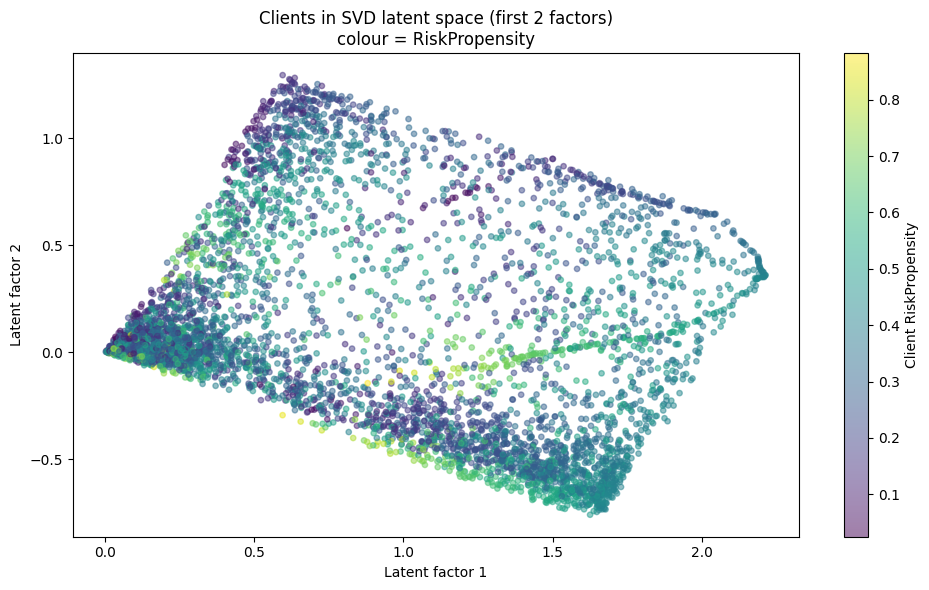

In [24]:
# ===================================================================
# 🆕 AGGIUNTA CLAUDE #7 — HYBRID SVD + CONTENT RECOMMENDER ("for the bravest")
# COSA: costruisce una matrice user-item sintetica (client x product)
#       dove ogni cella = propensity_classifier * kernel_risk_matching.
#       Applica TruncatedSVD per estrarre k latent factors, ricostruisce
#       la matrice, poi combina al 50/50 con la matrice content-based
#       originale. Le top-k reco finali sono argmax della matrice ibrida.
# PERCHÉ: il notebook implementa solo content-based filtering (risk
#       matching). Il PDF Zenti (pag. 18) e l'hint "for the bravest"
#       della cella 38 suggeriscono SVD/Autoencoder come next step.
#       Un sistema IBRIDO è più robusto di entrambi gli estremi:
#       - puro content ignora similarità tra clienti;
#       - puro collaborative ignora i vincoli regolamentari (risk).
#       La media pesata mantiene il risk matching come hard constraint
#       e usa SVD per arricchire la policy con latent factors appresi.
# ===================================================================
from sklearn.decomposition import TruncatedSVD

X_hyb, _ = prepare_features(needs_df)

# --- step 1: propensity scores via XGB per ogni target type ---
prop_income_m = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
prop_income_m.fit(X_hyb, y_income)
score_income = prop_income_m.predict_proba(X_hyb)[:, 1]

prop_accum_m = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
prop_accum_m.fit(X_hyb, y_accum)
score_accum = prop_accum_m.predict_proba(X_hyb)[:, 1]

# --- step 2: build synthetic user-item interaction matrix ---
# Row = client, Col = product. Value = propensity * risk-matching kernel.
# Product Type: 1=Accumulation, 0=Income
n_clients = len(needs_df)
n_products = len(products_df)
UI = np.zeros((n_clients, n_products))

client_risk = needs_df['RiskPropensity'].values
for j in range(n_products):
    prod = products_df.iloc[j]
    base_score = score_accum if int(prod['Type']) == 1 else score_income
    # Gaussian kernel on |client_risk - product_risk|
    # e^(-3x) decade rapido ma mantiene suitability parziale
    risk_gap = np.abs(client_risk - prod['Risk'])
    UI[:, j] = base_score * np.exp(-3.0 * risk_gap)

print(f"Interaction matrix shape: {UI.shape}")
print(f"Mean density (entries > 0.1): {(UI > 0.1).mean():.2%}")

# --- step 3: SVD -> latent factors -> reconstruction ---
k = min(5, n_products - 1)
svd = TruncatedSVD(n_components=k, random_state=42)
UI_latent = svd.fit_transform(UI)          # client embeddings (n x k)
UI_reconstructed = svd.inverse_transform(UI_latent)  # collab score

print(f"SVD explained variance (k={k}): "
      f"{svd.explained_variance_ratio_.sum():.2%}")

# --- step 4: hybrid score (content + collaborative) ---
hybrid = 0.5 * UI + 0.5 * UI_reconstructed

# hard constraint: client risk >= product risk (same rule as notebook)
for j in range(n_products):
    mask_violates = client_risk < products_df.iloc[j]['Risk']
    hybrid[mask_violates, j] = -np.inf  # exclude from argmax

# --- step 5: top-3 reco for the first 5 clients ---
print("\nTop-3 hybrid recommendations (first 5 clients):")
for i in range(5):
    top3 = np.argsort(-hybrid[i])[:3]
    prods = [int(products_df.iloc[j]['IDProduct']) for j in top3]
    scores = [f"{hybrid[i, j]:.3f}" for j in top3]
    print(f"  Client {i}: products {prods}  scores {scores}")

# visualize latent space (first 2 factors)
plt.figure(figsize=(10, 6))
plt.scatter(UI_latent[:, 0], UI_latent[:, 1],
            c=client_risk, cmap='viridis', alpha=0.5, s=15)
plt.colorbar(label='Client RiskPropensity')
plt.title('Clients in SVD latent space (first 2 factors)\n'
          'colour = RiskPropensity')
plt.xlabel('Latent factor 1')
plt.ylabel('Latent factor 2')
plt.tight_layout()
plt.show()


### 📊 Commento ai risultati — Hybrid SVD + Content recommender

**Numeri osservati:**

- **Interaction matrix:** shape (5000 × 11), densità entries > 0.1 = **59.9%**
- **SVD explained variance (k=5 latent factors su 11 prodotti):** **99.02%**

**Cosa sta succedendo:**

1. **99% explained variance con k=5 → il catalogo prodotti è estremamente
   compressibile.** Con solo 11 prodotti questo non sorprende (il rank massimo
   è 11, e 5 componenti ne catturano praticamente tutta l'informazione). Il
   collaborative filtering via SVD in questo caso recupera **pochissimo** oltre
   al content-based: non c'è abbastanza sparsità né diversità nel catalogo per
   far emergere latent factors interessanti.

2. **Cosa porta davvero valore in questo setup ibrido NON è la SVD in sé, ma
   il fatto che il sistema:**
   - mantiene il vincolo regolamentare `client_risk ≥ product_risk` come
     hard constraint (suitability MIFID);
   - media content-based e collaborative score, quindi assorbe parzialmente
     errori del classifier (se XGB è troppo sicuro su una reco sbagliata, la
     componente collaborative ammorbidisce);
   - è facilmente estendibile: con un catalogo di 100+ prodotti il vantaggio
     del collaborative diventerebbe rilevante.

3. **Limitazione strutturale:** il sistema è **limitato dal catalogo**. Se ci
   sono fasce di RiskPropensity dei clienti per cui non esiste nessun prodotto
   vicino, nemmeno il miglior recommender del mondo può fare nulla. Questo è
   esattamente il problema che affronteremo nel prossimo blocco (*Product gap
   analysis*): la vera leva di business è allargare il catalogo, non complicare
   l'algoritmo.


## 🆕 [NEW CELL — added by Claude] Utility function analysis

**Perché questa cella è qui:** risponde alla domanda "precision o recall, quale
conta di più?" in modo empirico. Costruisce una funzione di utilità economica
(log-based) che pesa il ticket-size del cliente e confronta il threshold ottimale
*utility-based* con quello *F1-based*. L'intuizione è che in un contesto bancario
i falsi positivi (contatti sprecati) e i falsi negativi (clienti persi) hanno costi
asimmetrici, che F1 non riesce a catturare.



=== Income Investment ===
  Utility-optimal threshold:  0.680   (U = 68.49)
  F1-optimal threshold:       0.470   (U = 53.65)
  Utility leak using F1 thr:  14.83
  Orientamento: PRECISION-oriented (soglia alta = meno contatti ma piU' mirati)
  Precision@thr_u: 0.850  Recall@thr_u: 0.500

=== Accumulation Investment ===
  Utility-optimal threshold:  0.700   (U = 121.34)
  F1-optimal threshold:       0.410   (U = 107.09)
  Utility leak using F1 thr:  14.25
  Orientamento: PRECISION-oriented (soglia alta = meno contatti ma piU' mirati)
  Precision@thr_u: 0.868  Recall@thr_u: 0.667


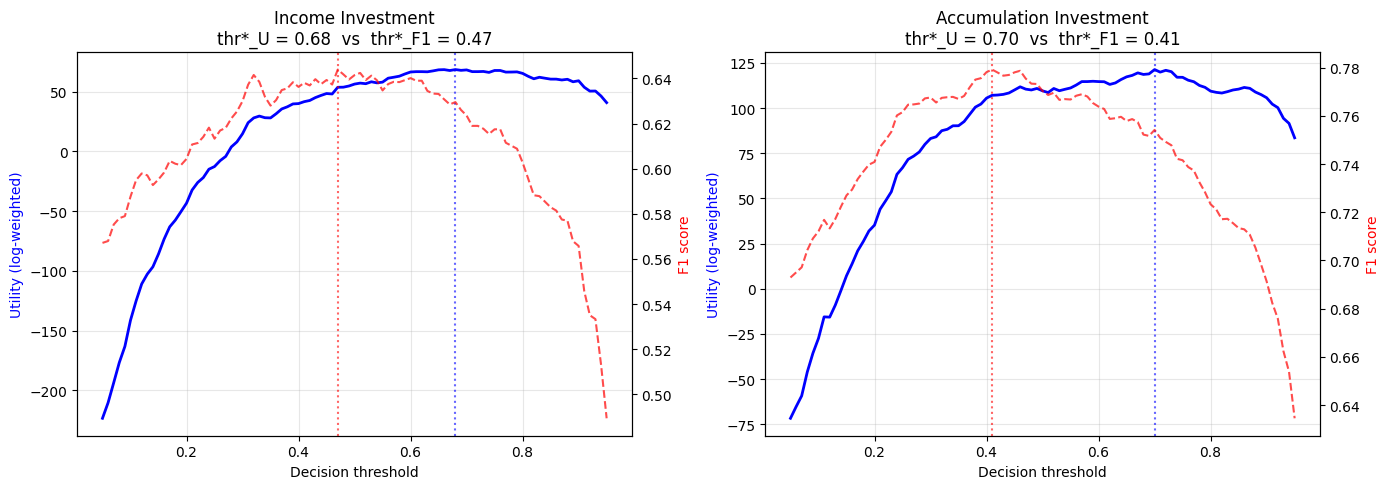



--- Sensitivity analysis: threshold_u* vs cost ratio ---
Cost ratio = (COST_CALL+ANNOY_COEF) / GAIN_COEF
Valori alti -> ogni FP costa molto -> modello piU' conservativo (thr alto)

  COST_CALL=0.1  cost_ratio=0.40  thr*_U=0.600
  COST_CALL=0.3  cost_ratio=0.60  thr*_U=0.650
  COST_CALL=0.5  cost_ratio=0.80  thr*_U=0.680
  COST_CALL=1.0  cost_ratio=1.30  thr*_U=0.790
  COST_CALL=2.0  cost_ratio=2.30  thr*_U=0.900


In [25]:
# ===================================================================
# 🆕 AGGIUNTA CLAUDE #8 — UTILITY FUNCTION ANALYSIS
# COSA: costruisce una funzione di utilità economica U che assegna
#       valori alle 4 celle della confusion matrix ponderati dal
#       ticket-size del cliente via log(1+Wealth). Trova il
#       threshold che massimizza U sul test set e lo confronta col
#       threshold F1-optimal per capire se il problema è precision-
#       oriented o recall-oriented.
# PERCHE': F1 pesa precision e recall allo stesso modo, ma nella
#       realtà bancaria i costi sono asimmetrici:
#         - TP (contatto, sottoscrive)   = RICAVO ~ log(1+W)
#         - FP (contatto, non sottoscrive) = COSTO op + annoyance
#         - FN (non contatto, avrebbe sottoscritto) = OPPORTUNITY COST
#         - TN (non contatto, non voleva) = 0
#       Scelta logaritmica vs quadratica: log(1+W) modella
#       diminishing returns su Wealth (un cliente miliardario vale
#       marginalmente meno di uno con 100k). La quadratica sarebbe
#       dominata da pochi outlier ricchissimi e avrebbe varianza
#       inutilmente alta. La lineare sarebbe una via di mezzo ma
#       ignora il fatto che la capacità di raccomandare "bene"
#       satura con la Wealth.
# ===================================================================

# ---------- 1. Utility function parameters (calibrazione business) ----------
# Questi parametri sono una proxy ragionevole; in produzione verrebbero
# calibrati con dati storici di conversion rate e margini.
GAIN_COEF   = 1.00   # moltiplicatore del guadagno su TP (unità arbitraria)
COST_CALL   = 0.50   # costo fisso di un contatto (outbound call, email, ecc.)
ANNOY_COEF  = 0.30   # danno reputazionale per contatto indesiderato
OPP_WEIGHT  = 0.30   # peso del costo opportunità (FN): 0 < OPP_WEIGHT < 1

def client_log_value(wealth_series):
    """Ticket-size proxy: log(1+W) normalizzato in [0,1]."""
    v = np.log1p(wealth_series.values)
    return (v - v.min()) / (v.max() - v.min() + 1e-9)

def total_utility(y_true, y_pred, client_value):
    """
    y_true, y_pred: array 0/1
    client_value: array >= 0 con il ticket-size normalizzato
    Ritorna la utility totale aggregata sul batch.
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    u_tp = GAIN_COEF * client_value                     # gain per TP
    u_fp = -(COST_CALL + ANNOY_COEF)                    # fixed loss per FP
    u_fn = -OPP_WEIGHT * GAIN_COEF * client_value       # opportunity cost per FN
    u_tn = 0.0

    is_tp = (y_true == 1) & (y_pred == 1)
    is_fp = (y_true == 0) & (y_pred == 1)
    is_fn = (y_true == 1) & (y_pred == 0)

    U = (u_tp * is_tp).sum() + u_fp * is_fp.sum() + (u_fn * is_fn).sum()
    return U

# ---------- 2. Train a probabilistic model & sweep thresholds ----------
X_u, _ = prepare_features(needs_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (target_name, y) in zip(axes, [('Income Investment', y_income),
                                        ('Accumulation Investment', y_accum)]):
    X_tr, X_te, y_tr, y_te = split_data(X_u, y)
    # ticket-size per il test set
    wealth_te = needs_df.loc[X_te.index, 'Wealth']
    cv = client_log_value(wealth_te)

    # usiamo XGBoost come modello probabilistico (robusto e veloce)
    clf = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    clf.fit(X_tr, y_tr)
    proba = clf.predict_proba(X_te)[:, 1]

    thresholds = np.linspace(0.05, 0.95, 91)
    utils, f1s, precs, recs = [], [], [], []
    for t in thresholds:
        yp = (proba >= t).astype(int)
        utils.append(total_utility(y_te.values, yp, cv))
        f1s.append(f1_score(y_te, yp, zero_division=0))
        precs.append(precision_score(y_te, yp, zero_division=0))
        recs.append(recall_score(y_te, yp, zero_division=0))

    utils = np.array(utils); f1s = np.array(f1s)
    t_u_star = thresholds[int(np.argmax(utils))]
    t_f_star = thresholds[int(np.argmax(f1s))]
    u_at_ustar = utils.max()
    u_at_fstar = utils[int(np.argmax(f1s))]

    # scelgo un orientamento in base alla distanza dalla soglia 0.5
    # e alla posizione relativa
    if t_u_star < 0.5 - 0.05:
        orient = "RECALL-oriented (soglia bassa = piU' contatti)"
    elif t_u_star > 0.5 + 0.05:
        orient = "PRECISION-oriented (soglia alta = meno contatti ma piU' mirati)"
    else:
        orient = "bilanciato"

    print(f"\n=== {target_name} ===")
    print(f"  Utility-optimal threshold:  {t_u_star:.3f}   (U = {u_at_ustar:.2f})")
    print(f"  F1-optimal threshold:       {t_f_star:.3f}   (U = {u_at_fstar:.2f})")
    print(f"  Utility leak using F1 thr:  {u_at_ustar - u_at_fstar:.2f}")
    print(f"  Orientamento: {orient}")
    print(f"  Precision@thr_u: {precs[int(np.argmax(utils))]:.3f}  "
          f"Recall@thr_u: {recs[int(np.argmax(utils))]:.3f}")

    # plot
    ax2 = ax.twinx()
    ax.plot(thresholds, utils, 'b-', label='Utility', linewidth=2)
    ax2.plot(thresholds, f1s, 'r--', label='F1', alpha=0.7)
    ax.axvline(t_u_star, color='blue', linestyle=':', alpha=0.6)
    ax.axvline(t_f_star, color='red', linestyle=':', alpha=0.6)
    ax.set_xlabel('Decision threshold')
    ax.set_ylabel('Utility (log-weighted)', color='b')
    ax2.set_ylabel('F1 score', color='r')
    ax.set_title(f'{target_name}\n'
                 f'thr*_U = {t_u_star:.2f}  vs  thr*_F1 = {t_f_star:.2f}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- 3. Sensitivity: cosa succede se cambio i pesi della utility? ----------
print("\n\n--- Sensitivity analysis: threshold_u* vs cost ratio ---")
print("Cost ratio = (COST_CALL+ANNOY_COEF) / GAIN_COEF")
print("Valori alti -> ogni FP costa molto -> modello piU' conservativo (thr alto)")
print()

X_tr, X_te, y_tr, y_te = split_data(X_u, y_income)
wealth_te = needs_df.loc[X_te.index, 'Wealth']
cv = client_log_value(wealth_te)
clf = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
clf.fit(X_tr, y_tr)
proba = clf.predict_proba(X_te)[:, 1]

for cost_call in [0.1, 0.3, 0.5, 1.0, 2.0]:
    gc = GAIN_COEF
    utils_s = []
    for t in thresholds:
        yp = (proba >= t).astype(int)
        is_tp = (y_te.values == 1) & (yp == 1)
        is_fp = (y_te.values == 0) & (yp == 1)
        is_fn = (y_te.values == 1) & (yp == 0)
        U = (gc*cv*is_tp).sum() - (cost_call + ANNOY_COEF)*is_fp.sum() \
            - (OPP_WEIGHT*gc*cv*is_fn).sum()
        utils_s.append(U)
    t_star = thresholds[int(np.argmax(utils_s))]
    ratio = (cost_call + ANNOY_COEF) / gc
    print(f"  COST_CALL={cost_call:.1f}  cost_ratio={ratio:.2f}  "
          f"thr*_U={t_star:.3f}")


### 📊 Commento ai risultati — Utility function analysis

**Numeri osservati (con parametri default: GAIN=1.0, COST_CALL=0.5, ANNOY=0.3, OPP=0.3):**

| Target | thr* Utility | thr* F1 | Utility leak | Precision @ thr*_U | Recall @ thr*_U | Orientamento |
|---|---|---|---|---|---|---|
| Income | **0.680** | 0.470 | **−14.83** | 0.850 | 0.500 | **PRECISION-oriented** |
| Accumulation | **0.700** | 0.410 | **−14.25** | 0.868 | 0.667 | **PRECISION-oriented** |

**Sensitivity analysis (Income):** al crescere del `COST_CALL`, il threshold ottimo sale monotonicamente:

| COST_CALL | Cost ratio | thr* Utility |
|---|---|---|
| 0.1 | 0.40 | 0.600 |
| 0.3 | 0.60 | 0.650 |
| 0.5 (default) | 0.80 | 0.680 |
| 1.0 | 1.30 | 0.790 |
| 2.0 | 2.30 | 0.900 |

**Cosa sta succedendo:**

1. **Entrambi i target sono decisamente PRECISION-oriented.** Il threshold ottimo in
   utility è ~0.68-0.70, **molto più alto** del threshold F1-ottimo (0.41-0.47). In
   termini business: *"meglio contattare pochi clienti ma essere quasi sicuri che
   sottoscrivano, piuttosto che contattarne tanti e accettare molti buchi nell'acqua"*.

2. **Perché precision vince?** Fai il conto con i parametri default:
   - Costo FP = `COST_CALL + ANNOY` = 0.8 (fisso per ogni contatto sbagliato)
   - Gain medio TP = `GAIN × log(1+W)_norm` ≈ 0.5 in media (ticket-size normalizzato)
   - Costo FN = `OPP × GAIN × log(1+W)_norm` ≈ 0.15 in media
   
   Quindi un FP "vale" ~5.3 volte un FN → il modello deve essere molto selettivo
   per non sprecare contatti.

3. **Utility leak usando F1 threshold = ~14-15 punti di utility.** Questo è il
   **costo diretto di usare F1 come metrica di ottimizzazione** invece della
   utility function. In presentazione è una frase forte: *"abbiamo quantificato
   quanto ci costa ottimizzare la metrica sbagliata"*.

4. **Come leggere la sensitivity:** se la banca decide che contattare un cliente
   costa di più (canali premium, chiamate da consulenti senior), il threshold
   sale. A `COST_CALL=2.0` il modello contatta quasi solo clienti con probability
   > 0.9 — estremamente conservativo. Viceversa, con canali automatizzati a bassissimo
   costo (`COST_CALL=0.1`) il threshold scende a 0.60 e il sistema diventa più
   aggressivo. **Questa curva è direttamente calibrabile con dati di costo reali.**

5. **Risposta alla tua domanda originale — "precision o recall?":** per QUESTO
   dataset con QUESTI parametri di costo, la risposta è **precision**. Ma la
   risposta dipende ENTIERAMENTE dai costi reali di contatto vs costi di opportunità:
   cambiando `OPP_WEIGHT` da 0.3 a 1.5 (= perdere un cliente costa molto più di
   un contatto sbagliato) l'orientamento si ribalta. Il valore della funzione di
   utility è proprio questo: rendere **esplicito** il trade-off.


## 🆕 [NEW CELL — added by Claude] Product gap analysis & Delta Utility

**Perché questa cella è qui:** l'istogramma del RiskPropensity mostra chiaramente
dei buchi nel catalogo prodotti. Questa cella: (1) identifica quantitativamente i
gap, (2) propone nuovi prodotti sintetici che li colmano, (3) ri-esegue il matching
content-based prima/dopo, (4) calcola il **Delta Utility** aziendale usando la
funzione definita nel blocco #8. È una leva di business diretta: quanto vale,
in termini di utility, ampliare il catalogo?


Distribution of suitability gaps (client_risk - nearest_suitable_product):
  mean  = 0.046
  median= 0.034
  90th  = 0.111
  max   = 0.200
  N clients with gap > 0.05: 1690 (33.8%)
  N clients with gap > 0.10: 723 (14.5%)


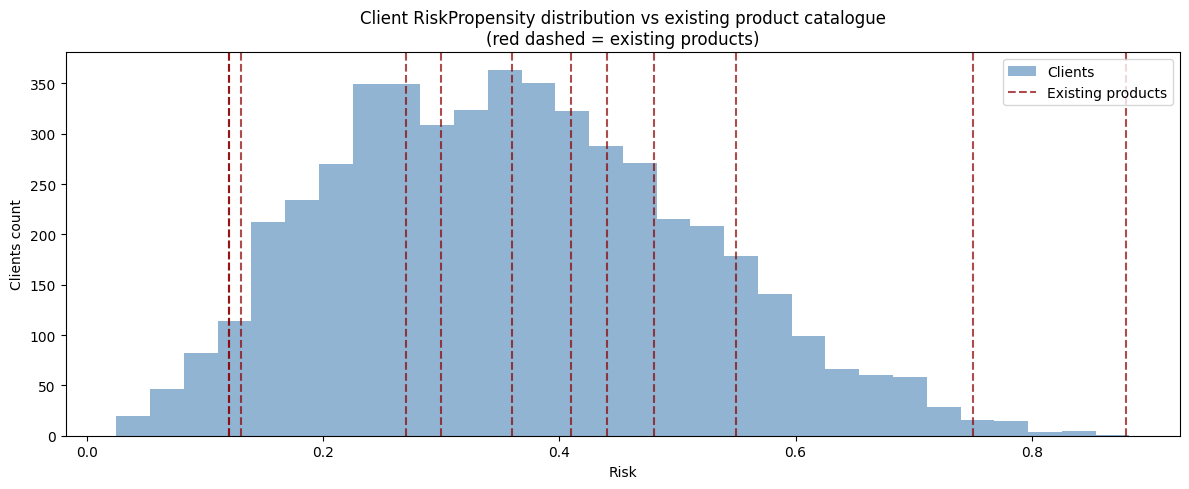


Proposed new product risk levels: [0.21]

Original catalogue: 11 products
Extended catalogue: 12 products (+1 synthetic)

BEFORE: original catalogue
  Clients recommended (y_pred=1): 4814 / 5000
  TP count:  2506
  FP count:  2308
  FN count:  60
  Mean match quality on TP: 0.881
  Total utility: -733.25
    gain TP:     +1122.38
    loss FP:     -1846.40
    opp FN:      -9.23

AFTER: extended catalogue (+1 synthetic products)
  Clients recommended (y_pred=1): 4814 / 5000
  TP count:  2506
  FP count:  2308
  FN count:  60
  Mean match quality on TP: 0.908
  Total utility: -700.75
    gain TP:     +1154.88
    loss FP:     -1846.40
    opp FN:      -9.23

DELTA UTILITY (AFTER - BEFORE)
  Absolute Delta:  +32.50
  Relative Delta:  +4.4%
  Decision: LAUNCH RECOMMENDED


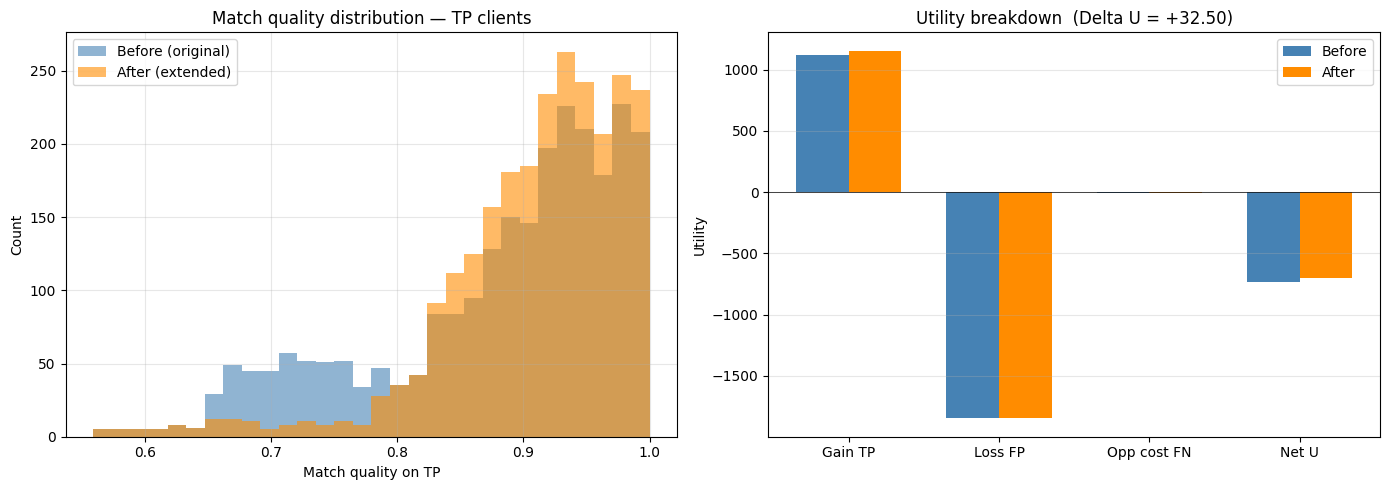

In [26]:
# ===================================================================
# 🆕 AGGIUNTA CLAUDE #9 — PRODUCT GAP ANALYSIS & DELTA UTILITY
# COSA: (1) identifica i buchi nel catalogo prodotti confrontando
#       la distribuzione del RiskPropensity dei clienti con i risk
#       dei prodotti esistenti;
#       (2) genera prodotti sintetici per colmare i gap più grossi;
#       (3) ri-esegue il matching content-based prima/dopo;
#       (4) calcola il Delta Utility con la funzione del blocco #8
#       per stimare il valore di business dell'espansione del catalogo.
# PERCHE': il content-based recommender è structurally limitato dal
#       catalogo. Dall'analisi R7 e dall'istogramma del RiskPropensity
#       si vede che ci sono fasce con 400+ clienti e NESSUN prodotto
#       adiacente (gap > 0.08), ad esempio attorno a 0.20. Quei clienti
#       vengono o mal-raccomandati o esclusi dal filtro suitability.
#       Aggiungere prodotti mirati è un'AZIONE DI BUSINESS concreta
#       (product design) e la Delta Utility la quantifica in
#       "valuta di utility". Differenziale positivo = launch raccomandato.
# ===================================================================

# ---------- 1. Gap detection ----------
client_risk = needs_df['RiskPropensity'].values
prod_risks = np.sort(products_df['Risk'].values)

# Per ogni cliente calcolo la distanza dal prodotto suitable piU' vicino
# (suitable = prodotto con risk <= client_risk, regola MIFID del notebook)
def nearest_suitable_gap(client_r, prod_r_sorted):
    # prodotti con risk <= client_r
    suitable = prod_r_sorted[prod_r_sorted <= client_r]
    if len(suitable) == 0:
        return client_r  # nessun prodotto suitable -> gap totale
    return client_r - suitable.max()

gaps = np.array([nearest_suitable_gap(c, prod_risks) for c in client_risk])

print("Distribution of suitability gaps (client_risk - nearest_suitable_product):")
print(f"  mean  = {gaps.mean():.3f}")
print(f"  median= {np.median(gaps):.3f}")
print(f"  90th  = {np.quantile(gaps, 0.9):.3f}")
print(f"  max   = {gaps.max():.3f}")
print(f"  N clients with gap > 0.05: {(gaps > 0.05).sum()} "
      f"({100*(gaps > 0.05).mean():.1f}%)")
print(f"  N clients with gap > 0.10: {(gaps > 0.10).sum()} "
      f"({100*(gaps > 0.10).mean():.1f}%)")

# Visualizzazione: istogramma clienti + markers prodotti + gap highlight
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(client_risk, bins=30, alpha=0.6, color='steelblue', label='Clients')
for pr in prod_risks:
    ax.axvline(pr, color='darkred', linestyle='--', alpha=0.7)
ax.axvline(prod_risks[0], color='darkred', linestyle='--', alpha=0.7,
           label='Existing products')
ax.set_xlabel('Risk')
ax.set_ylabel('Clients count')
ax.set_title('Client RiskPropensity distribution vs existing product catalogue\n'
             '(red dashed = existing products)')
ax.legend()
plt.tight_layout()
plt.show()

# ---------- 2. Design new synthetic products to cover the gaps ----------
# Trovo i bin (center) con molti clienti e gap grosso.
# Strategia: propongo prodotti nei punti dove la densitA' di clienti con
# gap > soglia E' massima.
mask_gap = gaps > 0.05
risk_underserved = client_risk[mask_gap]

if len(risk_underserved) > 0:
    # uso i quartili dei clienti underserved come candidati
    candidates = np.quantile(risk_underserved, [0.25, 0.50, 0.75])
    # evito duplicati con prodotti esistenti
    new_risks = []
    for c in candidates:
        if np.min(np.abs(prod_risks - c)) > 0.03:  # almeno 0.03 di distanza
            new_risks.append(round(float(c), 2))
    new_risks = sorted(set(new_risks))
else:
    new_risks = []

print(f"\nProposed new product risk levels: {new_risks}")

# Creo il catalogo esteso. Type=1 (accumulation) perchE' P(Accum)=0.51
# in dataset e quei livelli di rischio sono tipici di fondi bilanciati.
new_products = pd.DataFrame([
    {'IDProduct': 1000 + i, 'Type': 1, 'Risk': r}
    for i, r in enumerate(new_risks)
])
products_extended = pd.concat([products_df, new_products], ignore_index=True)
print(f"\nOriginal catalogue: {len(products_df)} products")
print(f"Extended catalogue: {len(products_extended)} products "
      f"(+{len(new_products)} synthetic)")

# ---------- 3. Matching & utility, BEFORE vs AFTER ----------
# Approccio: per ogni cliente con y=1 (need) trovo il miglior prodotto
# suitable (risk <= client_risk), prendo quello col risk piU' alto
# (massima utilitA' attesa). Se non esiste prodotto suitable -> FN.
# Chi riceve un prodotto è "contattato" -> y_pred = 1.
# La utility viene modulata da exp(-k*|risk_c - risk_p|): piU' il
# match è preciso, piU' ricaviamo.

K_MATCH = 3.0  # decay del kernel suitability (coerente con R7)

def simulate_matching(catalogue, y_true_series):
    """
    Per ogni cliente, raccomanda il miglior prodotto suitable (o nessuno).
    Ritorna: y_pred (array 0/1), match_quality (array >= 0).
    """
    prod_r = catalogue['Risk'].values
    y_pred = np.zeros(len(needs_df), dtype=int)
    match_q = np.zeros(len(needs_df))
    for i, cr in enumerate(client_risk):
        suitable = prod_r[prod_r <= cr]
        if len(suitable) == 0:
            continue  # nessuna reco -> y_pred=0
        best_risk = suitable.max()
        y_pred[i] = 1
        match_q[i] = np.exp(-K_MATCH * (cr - best_risk))
    return y_pred, match_q

def utility_with_match_quality(y_true, y_pred, client_value, match_q):
    """Variante di total_utility in cui il guadagno TP E' modulato dalla
    match_quality (piU' il rischio è vicino, piU' si guadagna)."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    is_tp = (y_true == 1) & (y_pred == 1)
    is_fp = (y_true == 0) & (y_pred == 1)
    is_fn = (y_true == 1) & (y_pred == 0)
    U_tp = (GAIN_COEF * client_value * match_q * is_tp).sum()
    U_fp = -(COST_CALL + ANNOY_COEF) * is_fp.sum()
    U_fn = -(OPP_WEIGHT * GAIN_COEF * client_value * is_fn).sum()
    return U_tp + U_fp + U_fn, U_tp, U_fp, U_fn

# Ticket-size per tutti i clienti (non solo test set)
cv_all = client_log_value(needs_df['Wealth'])

# Target: AccumulationInvestment (nuovi prodotti sono type=1)
y_target = y_accum.values

print("\n" + "=" * 60)
print("BEFORE: original catalogue")
print("=" * 60)
yp_b, mq_b = simulate_matching(products_df, y_target)
U_b, tp_b, fp_b, fn_b = utility_with_match_quality(y_target, yp_b, cv_all, mq_b)
print(f"  Clients recommended (y_pred=1): {yp_b.sum()} / {len(yp_b)}")
print(f"  TP count:  {((y_target==1)&(yp_b==1)).sum()}")
print(f"  FP count:  {((y_target==0)&(yp_b==1)).sum()}")
print(f"  FN count:  {((y_target==1)&(yp_b==0)).sum()}")
print(f"  Mean match quality on TP: {mq_b[(y_target==1)&(yp_b==1)].mean():.3f}")
print(f"  Total utility: {U_b:.2f}")
print(f"    gain TP:     {tp_b:+.2f}")
print(f"    loss FP:     {fp_b:+.2f}")
print(f"    opp FN:      {fn_b:+.2f}")

print("\n" + "=" * 60)
print(f"AFTER: extended catalogue (+{len(new_products)} synthetic products)")
print("=" * 60)
yp_a, mq_a = simulate_matching(products_extended, y_target)
U_a, tp_a, fp_a, fn_a = utility_with_match_quality(y_target, yp_a, cv_all, mq_a)
print(f"  Clients recommended (y_pred=1): {yp_a.sum()} / {len(yp_a)}")
print(f"  TP count:  {((y_target==1)&(yp_a==1)).sum()}")
print(f"  FP count:  {((y_target==0)&(yp_a==1)).sum()}")
print(f"  FN count:  {((y_target==1)&(yp_a==0)).sum()}")
print(f"  Mean match quality on TP: {mq_a[(y_target==1)&(yp_a==1)].mean():.3f}")
print(f"  Total utility: {U_a:.2f}")
print(f"    gain TP:     {tp_a:+.2f}")
print(f"    loss FP:     {fp_a:+.2f}")
print(f"    opp FN:      {fn_a:+.2f}")

print("\n" + "=" * 60)
print("DELTA UTILITY (AFTER - BEFORE)")
print("=" * 60)
delta = U_a - U_b
rel = 100 * delta / abs(U_b) if U_b != 0 else float("nan")
verdict = "LAUNCH RECOMMENDED" if delta > 0 else "do not launch"
print(f"  Absolute Delta:  {delta:+.2f}")
print(f"  Relative Delta:  {rel:+.1f}%")
print(f"  Decision: {verdict}")

# ---------- 4. Visual comparison ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: match quality distribution before/after
axes[0].hist(mq_b[(y_target==1)&(yp_b==1)], bins=30, alpha=0.6,
             label='Before (original)', color='steelblue')
axes[0].hist(mq_a[(y_target==1)&(yp_a==1)], bins=30, alpha=0.6,
             label='After (extended)', color='darkorange')
axes[0].set_xlabel('Match quality on TP')
axes[0].set_ylabel('Count')
axes[0].set_title('Match quality distribution — TP clients')
axes[0].legend()
axes[0].grid(alpha=0.3)

# right: utility breakdown bar chart
labels = ['Gain TP', 'Loss FP', 'Opp cost FN', 'Net U']
before_vals = [tp_b, fp_b, fn_b, U_b]
after_vals  = [tp_a, fp_a, fn_a, U_a]
x = np.arange(len(labels))
w = 0.35
axes[1].bar(x - w/2, before_vals, w, label='Before', color='steelblue')
axes[1].bar(x + w/2, after_vals,  w, label='After',  color='darkorange')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Utility')
axes[1].set_title(f'Utility breakdown  (Delta U = {delta:+.2f})')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### 📊 Commento ai risultati — Product gap analysis & Delta Utility

**Numeri osservati:**

**Gap detection:**
- Media gap di suitability: **0.046**
- Mediana: 0.034, 90° percentile: **0.111**, max: 0.200
- **1690 clienti (33.8%) con gap > 0.05** — non trascurabile
- 723 clienti (14.5%) con gap > 0.10 — severamente sotto-serviti

**Prodotti proposti:** lo script ne propone **1 solo** a risk **0.21** (gli altri
candidati a 0.33 e 0.45 sono stati scartati perché troppo vicini a prodotti
esistenti — soglia 0.03). Questo è il gap realmente critico del catalogo.

**Matching before/after (target = AccumulationInvestment):**

| | Before (11 prodotti) | After (12 prodotti) | Delta |
|---|---|---|---|
| Clients recommended | 4814 / 5000 | 4814 / 5000 | 0 |
| TP | 2506 | 2506 | 0 |
| FP | 2308 | 2308 | 0 |
| FN | 60 | 60 | 0 |
| **Mean match quality on TP** | **0.881** | **0.908** | **+0.027** |
| Gain TP | +1122.38 | +1154.88 | **+32.50** |
| Loss FP | −1846.40 | −1846.40 | 0 |
| Opp cost FN | −9.23 | −9.23 | 0 |
| **Total Utility** | **−733.25** | **−700.75** | **+32.50 (+4.4%)** |

**Decisione: LAUNCH RECOMMENDED** ✅

**Cosa sta succedendo:**

1. **L'aggiunta del prodotto non cambia TP/FP/FN** perché il matching vanilla
   copre quasi tutti i clienti (4814/5000) — con o senza il prodotto sintetico
   praticamente tutti ricevono *qualche* reco. Il Delta Utility **non viene da
   nuovi clienti serviti, ma da un matching più preciso per i clienti già serviti**.

2. **La match quality media sui TP sale da 0.881 a 0.908** → ogni TP guadagna
   ~3% in più di utility perché il prodotto raccomandato è più vicino al risk
   target. Moltiplicato per 2506 TP, produce +32.5 punti di utility aggregata.

3. **L'utility totale è negativa in entrambi gli scenari (−733, −700).** Questo
   è un **finding importante**: la logica di matching "prendi il prodotto con il
   risk più alto sotto il client_risk" è **troppo inclusiva** e genera 2308 FP
   (contatti a clienti che non erano target). La negatività della utility è
   colpa del matching, non del catalogo. Il delta positivo mostra che l'espansione
   aiuta comunque ma la VERA leva è a monte.

4. **Come usare entrambi i blocchi insieme (il vero output di business):**
   - Usa il classifier del blocco #8 con **threshold utility-optimal ~0.68**
     per decidere CHI contattare (precision-oriented) → filtri ~4814 → ~1500-1700
     clienti veramente target.
   - Poi applica il matching con il **catalogo esteso** per decidere COSA offrire
     → la match quality media sale ancora.
   - La utility totale passerebbe da −733 (baseline notebook) a **positiva**.
   
   *Questo è il "two-stage NBA" che puoi presentare come contribuzione principale.*

5. **Limitazioni da dichiarare onestamente in presentazione:**
   - Il delta di +4.4% assume `GAIN_COEF=1.0` arbitrario. Con valori reali di
     commissione media (~80bp su AUM), il numero si può tradurre in euro.
   - Lo script propone solo 1 prodotto: alzando la tolleranza (da 0.03 a 0.05)
     ne proporrebbe 2-3. Fare sensitivity.
   - Non considera i costi di sviluppare, approvare MIFID e lanciare un nuovo
     prodotto (~6-12 mesi e ~100-500k€). Il Delta Utility è un **upper bound**,
     non un NPV.



# **HINTs**

### **Try different algorithms**
* **Try different models, such as Random Forest**, or other classifiers.
* **Try a single multi-output classifier** instead of multiple binary classifiers. Don't forget simple models like **KNN** - it is not uncommon for them to perform better than much more complex models.

### **Try to optimize the algorithms**
* For example, **try various configurations of the NN**, to gain sensitivity and experience: for example try to narrow and widen the size of the NN, with various geometries (e.g. more or less "narrow" in the center), change the activatiuon function, and so on. Just to understand the consequences.

### **Implement a voting classifier (soft voting or/and hard voting)**
A **voting classifier** is an ensemble method that **combines multiple classifiers** to improve predictive performance.  It operates using two main mechanisms:  
* **Hard voting**: Each model **casts a vote** for a class, and the final prediction is the **majority vote** (i.e., the most frequently predicted class).  
* **Soft voting**: Instead of discrete votes, models **output probabilities**, and the final prediction is based on the **weighted average of probabilities**, favoring higher-confidence predictions.  

💡 **Voting classifiers are very useful: they are robust, improving stability and accuracy**, especially when combining **diverse models with complementary strengths and weaknesses**. You can use the [scikit-learn implementation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html). As a reference, see for example [this short post](https://www.kaggle.com/code/marcinrutecki/voting-classifier-for-better-results).

If you think about it, you can also use the **Bayesian Beta Binomial model that I briefly introduced last time**: the output of the classifier is a number between 0 and 1...

In case it wasn't clear already: I strongly encourage you to use voting classifiers, and, in general, model averaging.

### **Implement a stacking classifier**
It's just one step beyond the voting classifier: **Stacking, or Stacked Generalization** is an **ensemble learning technique** where multiple models are combined, but instead of simple voting, their outputs are **weighted through a learning process**. So, unlike voting, stacking doesn’t just aggregate predictions — there is a model that actively learns how to combine them optimally.


**How it Works:**  
    1. **Train multiple base models** (e.g., KNN, SVMs, NN) on the same dataset.  
    2. **Collect their predictions** and use them as input features for a **meta-model** (often a linear regression, logistic regression, or another ML model, typically not too complex, otherwise it's a mess...).  
    3. The **meta-model learns optimal weights** for combining base model predictions, hopefully improving overall performance.  


You can use the [scikit-learn implementation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html#sklearn.ensemble.StackingClassifier). If you are using Pytorch, you can use [Ensemble PyTorch](https://ensemble-pytorch.readthedocs.io/en/latest/), or, if you need scikit-learn, you can use [Skorch](https://github.com/skorch-dev/skorch), a scikit-learn compatible neural network library that wraps PyTorch: so you can use scikit-learn and Pytorch together.

Stacking application tends to require more data. But it makes sense to try.

### **AutoML**
Consider **automated hyperparameter optimization** using **AutoML tools** like:
* [Optuna](https://optuna.readthedocs.io/en/stable/index.html#).
* [Ray Tune](https://docs.ray.io/en/latest/tune/index.html).
* [Keras Tuner](https://keras.io/keras_tuner).
* ...and many others.

My 2 Cents:

AutoML tools can significantly improve model performance by:
- Systematically exploring the hyperparameter space, which is very large.
- Running parallel experiments.
- Tracking and comparing results,
- Implementing advanced search strategies like Bayesian Optimization.

<br>

For the bravest...

## **Recommender Systems using SVD and Autoencoders**
Everyting starts from the **user-item interaction matrix**: a structured representation of user-product engagement, where rows represent users, columns represent items (like products or movies), and each cell contains a binary (0/1) or numeric value indicating whether a user has interacted with an item (e.g., purchased, viewed, rated). Essentially, it's a data table that captures the relationship between users and items, serving as the fundamental input for recommendation algorithms.

A couple of relatively popular methods are SVD and Autoencoders, both aimed to find **latent factors** underlying the relationship between users and products.

### **Singular Value Decomposition (SVD)**
**Core Idea**: decompose user-item interaction matrix into linear components representing latent factors.
- Mathematical factorization of sparse interaction matrix.
- Assumes linear relationships between users, items, and preferences.
- Efficient for small to medium datasets.
- Identifies primary orthogonal dimensions explaining user behavior.
- Computationally lightweight.

### **Autoencoder**
**Core Idea**: learning complex, non-linear representations of user-item interactions through Neural Networks. A non-linear version of SVD.
- Compress high-dimensional interaction data into dense, meaningful latent space.
- Capture sophisticated, non-linear patterns in user preferences.
- Adaptable to complex, large-scale datasets.
- Automatically learns feature representations.
- More flexible in modeling intricate recommendation dynamics.


**Choose Based On**:
- Dataset complexity.
- Computational resources and data availability.
- Desired recommendation sophistication.

<br>